In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

FECHA_FIN_DATOS_VENTAS = pd.Timestamp("2026-03-31")


# 0. Cargar Datos

## 0.1 Ventas

In [2]:
# Cargar datos
path_ventas = "datos/Ventas por Cliente/ventas_con_descuento_aplicado.csv"
ventas = pd.read_csv(path_ventas)
print("Ventas - Filas:", ventas.shape[0])
ventas.head()

/var/folders/dw/9r647bwd1kl_g5lxtz0kh4100000gp/T/ipykernel_41449/3181763947.py:3: DtypeWarning: Columns (0: dscto_volumen, 1: ids_descuento_volumen) have mixed types. Specify dtype option on import or set low_memory=False.
  ventas = pd.read_csv(path_ventas)


Ventas - Filas: 2157646


,cod_cliente,cod_canal_comercial,cod_consolidado,zona,distrito,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,...,precio_lista_por_unidad,descuento_pct_observado,descuento_pct_matcheado,diferencia_descuento_pct,descuento_aplicado,id_descuento_aplicado,calza_con_descuento,gap,monto_a_precio_lista,costo_descuento
0,1227986,HR,37,SANTIAGO,SANTIAGO CENTRO COSTA,2026-02-16,3112,SALAME PIEZA 1KG LP,8274,1.0,...,8274.0,0.000000e+00,0.0,0.000000e+00,ninguno,NaN,False,False,8274.0,0.0
1,1176438,HR,37,NORTE 1,ANTOFAGASTA,2026-02-04,8512,"SALCHICHON CERVEZA WINTER 1,8 KG",108216,27.0,...,7214.4,-1.110223e-14,0.0,-1.110223e-14,ninguno,NaN,False,False,108216.0,0.0
2,1035323,CB,54,NORTE 2,SAN FELIPE,2026-02-16,3112,SALAME PIEZA 1KG LP,7033,1.0,...,8274.0,-1.499879e+01,0.0,-1.499879e+01,ninguno,NaN,False,True,8274.0,1241.0
3,1011205,CB,32,SUR 1,RANCAGUA,2026-02-16,3112,SALAME PIEZA 1KG LP,7033,1.0,...,8274.0,-1.499879e+01,0.0,-1.499879e+01,ninguno,NaN,False,True,8274.0,1241.0
4,1035323,CB,54,NORTE 2,SAN FELIPE,2026-02-09,8517,SALCHICHON CERVEZA MINI PZA 8x400 GR WI,22308,12.0,...,1486.8,-4.998655e+01,0.0,-4.998655e+01,liquidacion_forzado,NaN,False,True,44604.0,22296.0


In [3]:
ventas.columns

Index(['cod_cliente', 'cod_canal_comercial', 'cod_consolidado', 'zona',
       'distrito', 'fecha_factura', 'cod_sku', 'nombre_sku', 'monto_real',
       'kilo_real', 'precio_real', 'precio_lista', 'dscto_base',
       'dscto_volumen', 'dscto_binario', 'carta_impacto', 'id_descuento_base',
       'ids_descuento_volumen', 'id_descuento_binario',
       'id_descuento_carta_impacto', 'año_factura', 'mes_factura',
       'kg_por_unidad', 'peso_variable', 'cantidad_unidades',
       'cantidad_unidades_entera', 'inconsistencia', 'precio_por_unidad',
       'precio_lista_por_unidad', 'descuento_pct_observado',
       'descuento_pct_matcheado', 'diferencia_descuento_pct',
       'descuento_aplicado', 'id_descuento_aplicado', 'calza_con_descuento',
       'gap', 'monto_a_precio_lista', 'costo_descuento'],
      dtype='str')

In [4]:
## Filtrar solo los canales relevantes
# {32: 'COBERTURA',
#  55: 'HORECA VOLUMEN',
#  37: 'OTROS HORECA',
#  54: 'VOLUMEN COBERTURA',
#  56: 'HR ACUERDOS COMERC.',
#  57: 'MAYORISTA B VOLUMEN',
#  70: 'HR CUENTAS CLAVES.',
#  38: 'OTROS MAYORISTAS',
#  67: 'MAYORISTAS CADENAS',
#  65: 'CHILECOMPRA'}
canales_relevantes = [
    32, # "COBERTURA",
    54, # "VOLUMEN COBERTURA",
    # "MAYORISTAS CADENAS",
    # "MAYORISTA B VOLUMEN",
    # "OTROS MAYORISTAS",
    # "HORECA VOLUMEN",
    # "OTROS HORECA",
]
ventas = ventas[ventas["cod_consolidado"].isin(canales_relevantes)].copy()
ventas["fecha_factura"] = pd.to_datetime(ventas["fecha_factura"])
ventas = ventas[ventas["fecha_factura"] <= FECHA_FIN_DATOS_VENTAS].copy()

assert ventas["fecha_factura"].max() <= FECHA_FIN_DATOS_VENTAS, (
    "Hay ventas posteriores a la fecha maxima del analisis."
)

print("Ventas después de filtrar canales irrelevantes y fecha de corte - Filas:", ventas.shape[0])
print("Fecha máxima de ventas usada:", ventas["fecha_factura"].max().strftime("%Y-%m-%d"))
ventas.head()


Ventas después de filtrar canales irrelevantes y fecha de corte - Filas: 1820155
Fecha máxima de ventas usada: 2026-03-31


,cod_cliente,cod_canal_comercial,cod_consolidado,zona,distrito,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,...,precio_lista_por_unidad,descuento_pct_observado,descuento_pct_matcheado,diferencia_descuento_pct,descuento_aplicado,id_descuento_aplicado,calza_con_descuento,gap,monto_a_precio_lista,costo_descuento
2,1035323,CB,54,NORTE 2,SAN FELIPE,2026-02-16,3112,SALAME PIEZA 1KG LP,7033,1.0,...,8274.0,-14.998792,0.0,-14.998792,ninguno,NaN,False,True,8274.0,1241.0
3,1011205,CB,32,SUR 1,RANCAGUA,2026-02-16,3112,SALAME PIEZA 1KG LP,7033,1.0,...,8274.0,-14.998792,0.0,-14.998792,ninguno,NaN,False,True,8274.0,1241.0
4,1035323,CB,54,NORTE 2,SAN FELIPE,2026-02-09,8517,SALCHICHON CERVEZA MINI PZA 8x400 GR WI,22308,12.0,...,1486.8,-49.986546,0.0,-49.986546,liquidacion_forzado,NaN,False,True,44604.0,22296.0
5,1123804,CB,32,NORTE 1,ANTOFAGASTA,2026-02-03,8512,"SALCHICHON CERVEZA WINTER 1,8 KG",14429,3.6,...,7214.4,0.001386,0.0,0.001386,ninguno,NaN,False,False,14428.8,-0.2
6,1067823,CB,54,NORTE 1,ANTOFAGASTA,2026-02-03,8512,"SALCHICHON CERVEZA WINTER 1,8 KG",18396,5.4,...,7214.4,-15.003326,-15.0,-0.003326,binario,4837.0,True,False,21643.2,3247.2


## 0.2 Descuentos consolidados

In [5]:
path_descuentos = "datos/Descuentos históricos/consolidado_descuentos.csv"
descuentos = pd.read_csv(path_descuentos)
print("Descuentos - Filas:", descuentos.shape[0])
descuentos.head()

Descuentos - Filas: 76509


,id_descuento,tipo_descuento,cod_sku,cod_canal,cod_consolidado,cod_cliente,fecha_inicio,fecha_fin,monto_descuento,__source_order
0,1,base,1006,CB,54.0,NaN,2026-03-02,2026-03-18,0.0,338
1,2,base,1006,CB,54.0,NaN,2026-03-19,9999-12-31,0.0,339
2,3,base,1006,HR,55.0,NaN,2026-03-02,2026-03-18,0.0,1118
3,4,base,1006,HR,55.0,NaN,2026-03-19,2026-03-29,0.0,1119
4,5,base,1006,HR,56.0,NaN,2023-11-01,2024-06-09,-24.8,1656


In [6]:
descuentos[descuentos["cod_consolidado"].isna()]

,id_descuento,tipo_descuento,cod_sku,cod_canal,cod_consolidado,cod_cliente,fecha_inicio,fecha_fin,monto_descuento,__source_order
44,45,base,1020,CB,NaN,NaN,2024-02-05,2024-02-29,-10.0,3643
4898,4899,carta_impacto,1006,NaN,NaN,1002215.0,2026-04-01,2026-04-10,2878.0,3422
4899,4900,carta_impacto,1006,NaN,NaN,1002667.0,2026-04-06,2026-04-10,2878.0,3629
4900,4901,carta_impacto,1006,NaN,NaN,1008117.0,2026-04-07,2026-04-10,2878.0,3732
4901,4902,carta_impacto,1006,NaN,NaN,1039197.0,2026-04-06,2026-04-10,2878.0,3975
...,...,...,...,...,...,...,...,...,...,...
74335,74336,carta_impacto,970,NaN,NaN,92024.0,2026-04-01,2026-04-30,3746.0,20539
75634,75635,volumen,6770,CB,NaN,NaN,2024-04-15,2024-04-25,-21.2,2179
75696,75697,volumen,6771,CB,NaN,NaN,2024-04-15,2024-04-25,-26.8,2180
75843,75844,volumen,689,CB,NaN,NaN,2024-05-12,2024-05-25,-20.0,2178


In [7]:
descuentos[descuentos["tipo_descuento"]=="base"]["monto_descuento"].describe()

count    3588.000000
mean      -12.648690
std        13.395793
min       -57.100000
25%       -20.000000
50%        -6.000000
75%        -3.000000
max         0.000000
Name: monto_descuento, dtype: float64

## 0.3 Costos por SKU

In [8]:
# Un Excel con varias hojas, una por mes, mismas columnas en todas las hojas
# Concatenar todas las hojas en un solo DataFrame con una columna adicional que indique el mes
path_costos = "datos/Consolidado ABC SKU (oct25'-mar26') FINAL.xlsx"
lista_dfs_costos = []
xls = pd.ExcelFile(path_costos, engine="openpyxl")
for sheet_name in xls.sheet_names:
    df = pd.read_excel(xls, sheet_name=sheet_name, engine="openpyxl")
    df["Mes"] = sheet_name  # Agregar columna con el nombre de la hoja (mes)
    lista_dfs_costos.append(df)
costos = pd.concat(lista_dfs_costos, ignore_index=True)
print("Costos - Filas:", costos.shape[0])
costos.head()

Costos - Filas: 1362


,SKU,Kilos Finales,Facturación,Aporte,Costo,Frío Externo,Energía,Distribución Fijo,T Producción,Gastos DM Canales,...,Energía por kilo,Distribución Fijo por kilo,T Producción por kilo,Gastos DM Canales por kilo,Gastos DM Marketing por kilo,Reponer por kilo,Gastos. Zonales Directos por kilo,O. G. Fijos Indirectos por kilo,Otros Distribución Variable por kilo,Mes
0,20,58043.950,286856695,26338148.0,1.013134e+08,9.314235e+05,6.362547e+06,2.974402e+06,3.115924e+07,9.093773e+05,...,109.616023,51.243956,536.821480,15.667047,69.781019,107.213380,165.224788,356.538820,11.496824,Mar 26
1,27,3350.615,16824295,968263.0,5.162494e+06,5.376687e+04,3.672811e+05,1.716988e+05,2.182250e+06,3.914600e+04,...,109.616023,51.243956,651.298434,11.683227,70.917961,46.616111,174.134955,361.737830,1.065923,Mar 26
2,30,28289.940,139253232,10049703.0,6.186897e+07,4.539649e+05,3.201319e+06,1.449688e+06,1.750704e+07,2.934156e+05,...,113.161033,51.243956,618.843430,10.371729,69.481203,84.973946,173.792703,355.245462,7.533394,Mar 26
3,102,13133.700,74013452,5222723.0,2.788324e+07,2.107547e+05,1.313908e+06,6.730227e+05,3.367262e+06,2.479957e+05,...,100.040929,51.243956,256.383338,18.882393,79.456343,78.698590,153.891363,402.053980,30.895221,Mar 26
4,210,178055.860,617396049,48810519.0,1.852048e+08,3.635689e+06,1.116290e+07,9.124287e+06,9.683573e+07,1.623069e+06,...,62.693270,51.243956,543.850298,9.115506,48.949864,76.885585,100.209147,259.732670,11.442677,Mar 26


In [9]:
costos.columns

Index(['SKU', ' Kilos Finales', 'Facturación', 'Aporte', 'Costo',
       'Frío Externo', 'Energía', 'Distribución Fijo', 'T Producción',
       'Gastos DM Canales', 'Gastos DM Marketing', 'Reponer',
       'Gastos. Zonales Directos', 'O. G. Fijos Indirectos',
       'Otros Distribución Variable', 'Aporte por kilo', 'Costo por kilo',
       'Frío Externo por kilo', 'Energía por kilo',
       'Distribución Fijo por kilo', 'T Producción por kilo',
       'Gastos DM Canales por kilo', 'Gastos DM Marketing por kilo',
       'Reponer por kilo', 'Gastos. Zonales Directos por kilo',
       'O. G. Fijos Indirectos por kilo',
       'Otros Distribución Variable por kilo', 'Mes'],
      dtype='str')

In [10]:
cols_costos = ["Mes", "SKU", ' Kilos Finales', 'Facturación', 'Aporte', 'Costo',
       'Frío Externo', 'Energía', 'Distribución Fijo', 'T Producción',
       'Gastos DM Canales', 'Gastos DM Marketing', 'Reponer',
       'Gastos. Zonales Directos', 'O. G. Fijos Indirectos',
       'Otros Distribución Variable']

costos = costos[cols_costos]
costos.head()

,Mes,SKU,Kilos Finales,Facturación,Aporte,Costo,Frío Externo,Energía,Distribución Fijo,T Producción,Gastos DM Canales,Gastos DM Marketing,Reponer,Gastos. Zonales Directos,O. G. Fijos Indirectos,Otros Distribución Variable
0,Mar 26,20,58043.950,286856695,26338148.0,1.013134e+08,9.314235e+05,6.362547e+06,2.974402e+06,3.115924e+07,9.093773e+05,4.050366e+06,6.223088e+06,9.590299e+06,2.069492e+07,6.673211e+05
1,Mar 26,27,3350.615,16824295,968263.0,5.162494e+06,5.376687e+04,3.672811e+05,1.716988e+05,2.182250e+06,3.914600e+04,2.376188e+05,1.561926e+05,5.834592e+05,1.212044e+06,3.571497e+03
2,Mar 26,30,28289.940,139253232,10049703.0,6.186897e+07,4.539649e+05,3.201319e+06,1.449688e+06,1.750704e+07,2.934156e+05,1.965619e+06,2.403908e+06,4.916585e+06,1.004987e+07,2.131193e+05
3,Mar 26,102,13133.700,74013452,5222723.0,2.788324e+07,2.107547e+05,1.313908e+06,6.730227e+05,3.367262e+06,2.479957e+05,1.043556e+06,1.033604e+06,2.021163e+06,5.280456e+06,4.057686e+05
4,Mar 26,210,178055.860,617396049,48810519.0,1.852048e+08,3.635689e+06,1.116290e+07,9.124287e+06,9.683573e+07,1.623069e+06,8.715810e+06,1.368993e+07,1.784283e+07,4.624692e+07,2.037436e+06


In [11]:
costos_totales = costos.groupby(["SKU"]).sum().reset_index()
costos_totales.head()

,SKU,Mes,Kilos Finales,Facturación,Aporte,Costo,Frío Externo,Energía,Distribución Fijo,T Producción,Gastos DM Canales,Gastos DM Marketing,Reponer,Gastos. Zonales Directos,O. G. Fijos Indirectos,Otros Distribución Variable
0,20,Mar 26Feb 26Ene 26Dic 25Nov 25Oct 25,335586.218,1662597580,153623897.0,6.106304e+08,7.001417e+06,4.006351e+07,1.867814e+07,1.710162e+08,6.286412e+06,2.557901e+07,3.301842e+07,5.643622e+07,1.059107e+08,3.132913e+06
1,27,Mar 26Feb 26Ene 26Dic 25Nov 25Oct 25,19992.314,96892820,5081558.0,3.159423e+07,4.193767e+05,2.394141e+06,1.112293e+06,1.034808e+07,1.377657e+05,1.474946e+06,8.965587e+05,3.313494e+06,6.182961e+06,3.760482e+04
2,30,Mar 26Feb 26Ene 26Dic 25Nov 25Oct 25,166105.952,823931212,66366773.0,3.727935e+08,3.463517e+06,2.051210e+07,9.254694e+06,9.408060e+07,3.468700e+06,1.265933e+07,1.274087e+07,3.103956e+07,5.252660e+07,1.192458e+06
3,102,Mar 26Feb 26Ene 26Dic 25Nov 25Oct 25,76809.925,431581113,33333712.0,1.736206e+08,1.609275e+06,8.061725e+06,4.282384e+06,1.821598e+07,2.161787e+06,6.481077e+06,5.942076e+06,1.108287e+07,2.718273e+07,4.919939e+06
4,151,Dic 25Nov 25Oct 25,4611.500,16473437,110102.0,6.366029e+06,5.175683e+04,2.510712e+05,2.476763e+05,2.694126e+06,2.367651e+04,1.942270e+05,4.545280e+04,4.993600e+05,1.016952e+06,1.800514e+04


In [12]:
costos_totales["Margen Producción"] = (
    costos_totales["Facturación"]
    - costos_totales["Costo"]
    - costos_totales["Distribución Fijo"]
    - costos_totales["Frío Externo"]
)

In [13]:
costos_totales["Margen por Kilo"] = costos_totales["Margen Producción"] / costos_totales[" Kilos Finales"]

## 0.4 Datos SKU

In [64]:
path_info_sku = "datos/Subfamilia y subcategoría.xlsx"
info_sku = pd.read_excel(path_info_sku)
info_sku.head()

,sku,Subfamilia,Subcategora,Texto breve de material,Grupo art.,Creado el,estado,Válido de,GTPos,Denominación,...,Denominación.2,Tip Carne,Denom..1,Gr. Empaq.,envasado_granel,Gr. Carga,Denominación.3,Conservación,Jerarquía Clte.(Familia DP),Descripción
0,20,Arrollado,Arrollado Lomo c/Ají,ARROLLADO LOMO CON AJI SJ,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel
1,21,NaN,NaN,ARROLLADO LOMO CORTADO SJ,SJ,20.10.2005,Bloqueado,19.10.2020,NORM,Posición normal,...,INSTITUCIONAL,5,CERDO,5,ENVASADO,35,LAMINADOS,60,A00010000200003,Arrollados-Laminados-Autoservicio
2,25,NaN,NaN,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,SJ,27.01.2011,Bloqueado,08.04.2016,NORM,Posición normal,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
3,26,NaN,NaN,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,SJ,23.05.2013,Bloqueado,18.03.2020,NORM,Posición normal,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
4,27,Arrollado,Arrollado Lomo,ARROLLADO LOMO SIN AJI SJ,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel


In [ ]:
info_sku.columns
# Index(['sku', 'Subfamilia', 'Subcategora', 'Texto breve de material',
#        'Grupo art.', 'Creado el', 'estado', 'Válido de', 'GTPos',
#        'Denominación', 'Bruto', 'kg Neto', 'Un', 'Volumen', 'UV', 'Longitud',
#        'Ancho', 'Altura', 'SjL', 'IndÁr', 'TES', 'TSA', 'Ctd.MAC', 'TUA',
#        'InA', 'Parámetro de Ingreso', '% de Caducidad', 'UM.Venta', 'GrM',
#        'Denominación.1', 'Cat Mkt', 'Denom.', 'Segm Mkt', 'Denominación.2',
#        'Tip Carne', 'Denom..1', 'Gr. Empaq.', 'envasado_granel', 'Gr. Carga',
#        'Denominación.3', 'Conservación', 'Jerarquía Clte.(Familia DP)',
#        'Descripción'],
#       dtype='str')

In [67]:
path_seg_productos = "datos/Segmentacion_productos (1).xlsx"
seg_productos = pd.read_excel(path_seg_productos)
seg_productos.head()

,sku,familia_hana,marca,descripción,kilos,ingresos_m,margen_1_m,margen_2_m,ebitda_m,marca_normalizada,ebitda_pct,margen_pct,segmento_producto,Infaltables
0,3109,JAMON G2,LA PREFERIDA,JAMON SANDWICH LP,398390.580,2075342.036,1.320033e+06,758334.664456,623179.820711,la preferida,0.300278,0.636056,Héroe,Faltable
1,421,PATE,SAN JORGE,PATE TERNERA 8x125 GRS.SJ,508267.552,1954343.478,1.329923e+06,478819.218456,348340.995060,san jorge,0.178239,0.680496,Héroe,Faltable
2,970,CARNES,SAN JORGE,MOLIDA 14x250 GR SJ,411706.750,1811076.827,9.322576e+05,435391.298100,316841.069705,san jorge,0.174946,0.514753,Héroe,Faltable
3,6783,LACTEOS,Los Nogales,MANTEQUILLA 125 GRS x8 LOS NOGALES,179480.900,1732725.366,5.869634e+05,335079.432902,229628.847484,los nogales,0.132525,0.338752,Héroe,Faltable
4,210,FIAMBRES,SAN JORGE,FIAMBRE SANDWICH SJ,809267.352,2903166.617,2.010887e+06,960805.242614,766732.128914,san jorge,0.264102,0.692653,Héroe,210


In [ ]:
seg_productos.columns
# Index(['sku', 'familia_hana', 'marca', 'descripción', 'kilos', 'ingresos_m',
#        'margen_1_m', 'margen_2_m', 'ebitda_m', 'marca_normalizada',
#        'ebitda_pct', 'margen_pct', 'segmento_producto', 'Infaltables'],
#       dtype='str')

Index(['sku', 'familia_hana', 'marca', 'descripción', 'kilos', 'ingresos_m',
       'margen_1_m', 'margen_2_m', 'ebitda_m', 'marca_normalizada',
       'ebitda_pct', 'margen_pct', 'segmento_producto', 'Infaltables'],
      dtype='str')

# 1. Cruzar Datos y Filtrar

In [14]:
# Normalizar nombre y formato del tipo de descuento
# Nota: en algunos archivos puede aparecer escrito como "tipo_desuento".
if "tipo_descuento" not in descuentos.columns and "tipo_desuento" in descuentos.columns:
    descuentos = descuentos.rename(columns={"tipo_desuento": "tipo_descuento"})

descuentos["tipo_descuento"] = (
    descuentos["tipo_descuento"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# Filtramos descuentos para quedarnos solo con aquellos no nulos
descuentos = descuentos[descuentos["monto_descuento"] < 0].copy()

# Que no son cartas de impacto
descuentos = descuentos[descuentos["tipo_descuento"].fillna("") != "carta_impacto"].copy()

# Que son de un cod_consolidado presente en ventas
cod_consolidado_ventas = ventas["cod_consolidado"].unique()
descuentos = descuentos[descuentos["cod_consolidado"].isin(cod_consolidado_ventas)].copy()

# Que son de un periodo entre 2025 y 2026, ajustando descuentos abiertos al corte de ventas.
descuentos["fecha_fin_original"] = descuentos["fecha_fin"].astype("string").str.strip()
fecha_fin_normalizada = descuentos["fecha_fin_original"].replace(
    {"9999-12-31": FECHA_FIN_DATOS_VENTAS.strftime("%Y-%m-%d")}
)

descuentos["fecha_inicio"] = pd.to_datetime(descuentos["fecha_inicio"])
descuentos["fecha_fin"] = pd.to_datetime(fecha_fin_normalizada)

descuentos = descuentos[
    (descuentos["fecha_inicio"].dt.year >= 2025)
].copy()

n_fecha_fin_abierta = descuentos["fecha_fin_original"].eq("9999-12-31").sum()
mask_inicio_post_corte = descuentos["fecha_inicio"] > FECHA_FIN_DATOS_VENTAS
n_excluidos_inicio_post_corte = mask_inicio_post_corte.sum()

mask_fecha_fin_post_corte = descuentos["fecha_fin"] > FECHA_FIN_DATOS_VENTAS
n_finitos_recortados_post_corte = (
    mask_fecha_fin_post_corte
    & ~descuentos["fecha_fin_original"].eq("9999-12-31")
).sum()

descuentos.loc[mask_fecha_fin_post_corte, "fecha_fin"] = FECHA_FIN_DATOS_VENTAS
descuentos = descuentos[~mask_inicio_post_corte].copy()

mask_periodo_invalido = descuentos["fecha_fin"] < descuentos["fecha_inicio"]
n_excluidos_periodo_invalido = mask_periodo_invalido.sum()
descuentos = descuentos[~mask_periodo_invalido].copy()

assert descuentos["fecha_fin"].max() <= FECHA_FIN_DATOS_VENTAS, (
    "Hay descuentos con fecha_fin posterior a la fecha maxima del analisis."
)
assert (descuentos["fecha_fin"] >= descuentos["fecha_inicio"]).all(), (
    "Hay descuentos con fecha_fin anterior a fecha_inicio."
)

print("Descuentos después de filtrar - Filas:", descuentos.shape[0])
print("Descuentos con fecha_fin_original == 9999-12-31:", n_fecha_fin_abierta)
print("Descuentos finitos recortados por exceder 2026-03-31:", n_finitos_recortados_post_corte)
print("Descuentos excluidos por empezar después de 2026-03-31:", n_excluidos_inicio_post_corte)
print("Descuentos excluidos por periodo inválido tras el corte:", n_excluidos_periodo_invalido)


Descuentos después de filtrar - Filas: 1958
Descuentos con fecha_fin_original == 9999-12-31: 585
Descuentos finitos recortados por exceder 2026-03-31: 80
Descuentos excluidos por empezar después de 2026-03-31: 50
Descuentos excluidos por periodo inválido tras el corte: 0


# 2. Análisis Exploratorio

In [15]:
# Unidad correcta de análisis:
# no cambiamos el id_descuento original, sino que creamos un id_descuento_analisis.
# Dos registros pertenecen al mismo descuento si coinciden en:
# cod_sku, tipo_descuento, cod_canal, cod_consolidado, fecha_inicio y fecha_fin.
ID_COL_ANALISIS = "id_descuento_analisis"

COLUMNAS_LLAVE_DESCUENTO_ANALISIS = [
    "cod_sku",
    "tipo_descuento",
    "cod_canal",
    "cod_consolidado",
    "fecha_inicio",
    "fecha_fin",
]

def _ids_ordenados(serie):
    valores = pd.Series(serie.dropna().unique())
    valores_num = pd.to_numeric(valores, errors="coerce")
    if len(valores) > 0 and valores_num.notna().all():
        return sorted(valores_num.astype(int).tolist())
    return sorted(valores.astype(str).tolist())

def filtrar_ventas_por_llave(ventas_df, sku, canal, consolidado):
    filtro = (
        (ventas_df["cod_sku"] == sku)
        & (ventas_df["cod_canal_comercial"] == canal)
    )

    if pd.notna(consolidado) and str(consolidado).strip() != "":
        filtro = filtro & (ventas_df["cod_consolidado"] == consolidado)

    return ventas_df[filtro].copy()

def filtrar_ventas_por_ids_descuento(ventas_df, ids_descuento):
    ids_originales = pd.Series(ids_descuento)

    ids_num = pd.to_numeric(ids_originales, errors="coerce").dropna().unique()
    if len(ids_num) > 0:
        id_aplicado_num = pd.to_numeric(
            ventas_df["id_descuento_aplicado"],
            errors="coerce"
        )
        return ventas_df[id_aplicado_num.isin(ids_num)].copy()

    ids_str = ids_originales.dropna().astype(str).unique().tolist()
    return ventas_df[
        ventas_df["id_descuento_aplicado"].astype("string").isin(ids_str)
    ].copy()


TIPOS_DESCUENTO_ACTIVACION_PARCIAL = {"binario", "volumen"}

def _normalizar_tipo_descuento_activacion(valor):
    if pd.isna(valor):
        return ""

    valor = str(valor).strip().lower()

    if valor.startswith("binario"):
        return "binario"
    if valor.startswith("volumen"):
        return "volumen"

    return valor

def filtrar_ventas_periodo_descuento(
    ventas_df,
    ids_descuento,
    fecha_inicio,
    fecha_fin,
    tipo_descuento,
):
    """
    Filtra las ventas usadas para medir la demanda durante el periodo de descuento.

    Para descuentos de activación parcial (binario y volumen), la demanda del periodo
    debe considerar tanto las ventas con el descuento correspondiente como las ventas
    del mismo periodo y llave sin ningún descuento.

    Para el resto de los tipos de descuento se mantiene la lógica original: sólo ventas
    asociadas a los ids del descuento.
    """
    fecha_inicio = pd.to_datetime(fecha_inicio).normalize()
    fecha_fin = pd.to_datetime(fecha_fin).normalize()

    fechas_factura = pd.to_datetime(ventas_df["fecha_factura"]).dt.normalize()
    ventas_periodo = ventas_df[
        (fechas_factura >= fecha_inicio)
        & (fechas_factura <= fecha_fin)
    ].copy()

    ventas_descuento = filtrar_ventas_por_ids_descuento(
        ventas_periodo,
        ids_descuento,
    )

    tipo_norm = _normalizar_tipo_descuento_activacion(tipo_descuento)

    if tipo_norm not in TIPOS_DESCUENTO_ACTIVACION_PARCIAL:
        return ventas_descuento

    ventas_sin_descuento_periodo = ventas_periodo[
        ventas_periodo["descuento_aplicado"]
        .astype("string")
        .str.strip()
        .str.lower()
        .eq("ninguno")
    ].copy()

    return (
        pd.concat(
            [ventas_descuento, ventas_sin_descuento_periodo],
            axis=0,
        )
        .loc[lambda df: ~df.index.duplicated(keep="first")]
        .copy()
    )

descuentos = descuentos.sort_values(
    COLUMNAS_LLAVE_DESCUENTO_ANALISIS + ["id_descuento"]
).copy()

descuentos[ID_COL_ANALISIS] = (
    descuentos
    .groupby(COLUMNAS_LLAVE_DESCUENTO_ANALISIS, dropna=False)
    .ngroup()
    + 1
)

descuentos_analisis = (
    descuentos
    .groupby(ID_COL_ANALISIS, as_index=False)
    .agg(
        cod_sku=("cod_sku", "first"),
        tipo_descuento=("tipo_descuento", "first"),
        cod_canal=("cod_canal", "first"),
        cod_consolidado=("cod_consolidado", "first"),
        fecha_inicio=("fecha_inicio", "first"),
        fecha_fin=("fecha_fin", "first"),
        fecha_fin_original=("fecha_fin_original", _ids_ordenados),
        ids_descuento_originales=("id_descuento", _ids_ordenados),
        n_ids_descuento_originales=("id_descuento", "nunique"),
        monto_descuento_min=("monto_descuento", "min"),
        monto_descuento_max=("monto_descuento", "max"),
    )
)

descuentos_analisis["duracion_dias"] = (
    descuentos_analisis["fecha_fin"] - descuentos_analisis["fecha_inicio"]
).dt.days + 1

assert descuentos_analisis["duracion_dias"].min() > 0, (
    "Hay descuentos con duracion_dias menor o igual a cero."
)

descuentos_analisis["es_descuento_agrupado"] = (
    descuentos_analisis["n_ids_descuento_originales"] > 1
)

print("IDs descuento originales:", descuentos["id_descuento"].nunique())
print("Unidades de análisis:", descuentos_analisis[ID_COL_ANALISIS].nunique())
print(
    "IDs originales consolidados por agrupación:",
    descuentos["id_descuento"].nunique() - descuentos_analisis[ID_COL_ANALISIS].nunique()
)

descuentos_analisis.head()


IDs descuento originales: 1958
Unidades de análisis: 1250
IDs originales consolidados por agrupación: 708


,id_descuento_analisis,cod_sku,tipo_descuento,cod_canal,cod_consolidado,fecha_inicio,fecha_fin,fecha_fin_original,ids_descuento_originales,n_ids_descuento_originales,monto_descuento_min,monto_descuento_max,duracion_dias,es_descuento_agrupado
0,1,20,binario,CB,32.0,2026-02-02,2026-02-28,[2026-02-28],[3824],1,-15.0,-15.0,27,False
1,2,20,binario,CB,54.0,2026-02-02,2026-02-28,[2026-02-28],[3825],1,-15.0,-15.0,27,False
2,3,20,volumen,CB,32.0,2026-03-02,2026-03-31,[9999-12-31],"[74649, 74650, 74651]",3,-20.0,-10.0,30,True
3,4,20,volumen,CB,54.0,2026-03-02,2026-03-31,[9999-12-31],"[74652, 74653, 74654]",3,-20.0,-10.0,30,True
4,5,27,binario,CB,32.0,2026-02-02,2026-02-28,[2026-02-28],[3890],1,-15.0,-15.0,27,False


In [16]:
# Verificación de la nueva unidad de análisis
assert descuentos["id_descuento"].nunique() == (
    descuentos[["id_descuento", ID_COL_ANALISIS]]
    .drop_duplicates()["id_descuento"]
    .nunique()
), "Hay ids originales sin asignación única a id_descuento_analisis."

assert descuentos_analisis[ID_COL_ANALISIS].is_unique, (
    "id_descuento_analisis debería ser único en descuentos_analisis."
)

print("Distribución de cantidad de ids originales por unidad de análisis:")
display(
    descuentos_analisis["n_ids_descuento_originales"]
    .value_counts()
    .sort_index()
    .rename_axis("n_ids_descuento_originales")
    .reset_index(name="n_unidades_analisis")
)

print("Ejemplos de descuentos agrupados:")
display(
    descuentos_analisis.loc[
        descuentos_analisis["es_descuento_agrupado"],
        [
            ID_COL_ANALISIS,
            "ids_descuento_originales",
            "n_ids_descuento_originales",
            "cod_sku",
            "tipo_descuento",
            "cod_canal",
            "cod_consolidado",
            "fecha_inicio",
            "fecha_fin",
            "fecha_fin_original",
            "monto_descuento_min",
            "monto_descuento_max",
        ],
    ].head(20)
)


Distribución de cantidad de ids originales por unidad de análisis:


,n_ids_descuento_originales,n_unidades_analisis
0,1,867
1,2,58
2,3,325


Ejemplos de descuentos agrupados:


,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,cod_sku,tipo_descuento,cod_canal,cod_consolidado,fecha_inicio,fecha_fin,fecha_fin_original,monto_descuento_min,monto_descuento_max
2,3,"[74649, 74650, 74651]",3,20,volumen,CB,32.0,2026-03-02,2026-03-31,[9999-12-31],-20.0,-10.0
3,4,"[74652, 74653, 74654]",3,20,volumen,CB,54.0,2026-03-02,2026-03-31,[9999-12-31],-20.0,-10.0
12,13,"[74661, 74662, 74663]",3,210,volumen,CB,32.0,2026-02-20,2026-03-01,[2026-03-01],-20.0,-10.0
13,14,"[74664, 74665, 74666]",3,210,volumen,CB,32.0,2026-03-02,2026-03-14,[2026-03-14],-20.0,-10.0
14,15,"[74667, 74668, 74669]",3,210,volumen,CB,32.0,2026-03-16,2026-03-31,[9999-12-31],-20.0,-10.0
15,16,"[74670, 74671, 74672]",3,210,volumen,CB,54.0,2026-02-20,2026-03-01,[2026-03-01],-20.0,-10.0
16,17,"[74673, 74674, 74675]",3,210,volumen,CB,54.0,2026-03-02,2026-03-14,[2026-03-14],-20.0,-10.0
17,18,"[74676, 74677, 74678]",3,210,volumen,CB,54.0,2026-03-16,2026-03-31,[9999-12-31],-20.0,-10.0
18,19,"[74685, 74686, 74687]",3,215,volumen,CB,32.0,2026-03-16,2026-03-31,[9999-12-31],-20.0,-10.0
19,20,"[74688, 74689, 74690]",3,215,volumen,CB,54.0,2026-03-16,2026-03-31,[9999-12-31],-20.0,-10.0


In [17]:
# Fijamos un id_descuento original de referencia.
# Si pertenece a un descuento de volumen con varios tramos, se analizará junto con todos
# los ids originales que compartan la llave de negocio.
ID_DESCUENTO_ORIGINAL_EJEMPLO = 74437  # descuentos["id_descuento"].values[1]

descuento_original_ejemplo = descuentos.loc[
    descuentos["id_descuento"] == ID_DESCUENTO_ORIGINAL_EJEMPLO
]

if descuento_original_ejemplo.empty:
    ID_DESCUENTO_ORIGINAL_EJEMPLO = descuentos["id_descuento"].iloc[0]
    descuento_original_ejemplo = descuentos.loc[
        descuentos["id_descuento"] == ID_DESCUENTO_ORIGINAL_EJEMPLO
    ]

ID_DESCUENTO_ANALISIS_EJEMPLO = descuento_original_ejemplo[ID_COL_ANALISIS].iloc[0]

descuento_ejemplo = descuentos_analisis.loc[
    descuentos_analisis[ID_COL_ANALISIS] == ID_DESCUENTO_ANALISIS_EJEMPLO
].iloc[0]

IDS_DESCUENTO_ORIGINALES_EJEMPLO = descuento_ejemplo["ids_descuento_originales"]

# Buscamos la llave primaria del descuento agrupado
SKU_EJEMPLO = descuento_ejemplo["cod_sku"]
COD_CANAL_EJEMPLO = descuento_ejemplo["cod_canal"]
COD_CONSOLIDADO_EJEMPLO = descuento_ejemplo["cod_consolidado"]


In [18]:
print("Ejemplo de descuento agrupado:")
print("ID Descuento original de referencia:", ID_DESCUENTO_ORIGINAL_EJEMPLO)
print("ID Descuento análisis:", ID_DESCUENTO_ANALISIS_EJEMPLO)
print("IDs originales incluidos:", IDS_DESCUENTO_ORIGINALES_EJEMPLO)
print("Número de ids originales incluidos:", len(IDS_DESCUENTO_ORIGINALES_EJEMPLO))
print("SKU:", SKU_EJEMPLO)
print("Código Canal:", COD_CANAL_EJEMPLO)
print("Código Consolidado:", COD_CONSOLIDADO_EJEMPLO)

fechas_desde = pd.to_datetime(descuento_ejemplo["fecha_inicio"])
fechas_hasta = pd.to_datetime(descuento_ejemplo["fecha_fin"])

print("Desde:", fechas_desde.strftime("%Y-%m-%d"))
print("Hasta:", fechas_hasta.strftime("%Y-%m-%d"))

dias_descuento = (fechas_hasta - fechas_desde).days + 1
print("Duración del descuento (días):", dias_descuento)
print("Monto mínimo del descuento:", descuento_ejemplo["monto_descuento_min"])
print("Monto máximo del descuento:", descuento_ejemplo["monto_descuento_max"])


Ejemplo de descuento agrupado:
ID Descuento original de referencia: 74437
ID Descuento análisis: 263
IDs originales incluidos: [74437, 74438, 74439]
Número de ids originales incluidos: 3
SKU: 1052
Código Canal: CB
Código Consolidado: 32.0
Desde: 2026-03-02
Hasta: 2026-03-31
Duración del descuento (días): 30
Monto mínimo del descuento: -20.0
Monto máximo del descuento: -10.0


## 2.1 Calcular baseline de contribución

In [19]:
ventas_llave_ejemplo = filtrar_ventas_por_llave(
    ventas,
    SKU_EJEMPLO,
    COD_CANAL_EJEMPLO,
    COD_CONSOLIDADO_EJEMPLO,
)

n_ventas_sku = ventas[ventas["cod_sku"] == SKU_EJEMPLO].shape[0]
n_ventas_sku_canal = ventas[
    (ventas["cod_sku"] == SKU_EJEMPLO)
    & (ventas["cod_canal_comercial"] == COD_CANAL_EJEMPLO)
].shape[0]
n_ventas_sku_canal_consolidado = ventas_llave_ejemplo.shape[0]

print(f"Número de ventas para SKU {SKU_EJEMPLO}: {n_ventas_sku}")
print(f"Número de ventas para SKU {SKU_EJEMPLO} en canal {COD_CANAL_EJEMPLO}: {n_ventas_sku_canal}")
print(
    f"Número de ventas para SKU {SKU_EJEMPLO} en canal {COD_CANAL_EJEMPLO} "
    f"y consolidado {COD_CONSOLIDADO_EJEMPLO}: {n_ventas_sku_canal_consolidado}"
)

# Determinar periodo sin ningún descuento aplicado
ventas_sin_descuento = ventas_llave_ejemplo[
    ventas_llave_ejemplo["descuento_aplicado"] == "ninguno"
].copy()

# Calcular cantidad de días sin descuento
ventas_sin_descuento["fecha_factura"] = pd.to_datetime(
    ventas_sin_descuento["fecha_factura"]
)
dias_sin_descuento = ventas_sin_descuento["fecha_factura"].nunique()

# Calcular demanda por día sin descuento
demanda_total_sin_descuento = ventas_sin_descuento["kilo_real"].sum()
demanda_diaria_sin_descuento = (
    demanda_total_sin_descuento / dias_sin_descuento
    if dias_sin_descuento > 0
    else np.nan
)

# Calcular rentabilidad por día en el periodo sin descuento
# Para esto, necesitamos el margen por kilo en el periodo sin descuento
margen_base_ejemplo = costos_totales.loc[
    costos_totales["SKU"] == SKU_EJEMPLO,
    "Margen por Kilo",
]
margen_por_kilo = (
    margen_base_ejemplo.iloc[0]
    if not margen_base_ejemplo.empty
    else np.nan
)
margen_diario_sin_descuento = demanda_diaria_sin_descuento * margen_por_kilo

# Print de todos los números clave
print(f"Periodo sin descuento: {dias_sin_descuento} días")
print(f"Demanda total sin descuento: {demanda_total_sin_descuento} kg")
print(f"Demanda diaria sin descuento: {demanda_diaria_sin_descuento} kg")
print(f"Margen por kilo: {margen_por_kilo}")
print(f"Rentabilidad diaria sin descuento: ${margen_diario_sin_descuento:.2f}")


Número de ventas para SKU 1052: 25
Número de ventas para SKU 1052 en canal CB: 25
Número de ventas para SKU 1052 en canal CB y consolidado 32.0: 23
Periodo sin descuento: 14 días
Demanda total sin descuento: 199.68000000000006 kg
Demanda diaria sin descuento: 14.262857142857147 kg
Margen por kilo: 1122.868675996664
Rentabilidad diaria sin descuento: $16015.32


## 2.2 Calcular contribución durante el descuento

In [20]:
# Determinar periodo del descuento aplicado.
# Para descuentos de volumen, se consideran todas las ventas asociadas a cualquiera
# de los ids originales que pertenecen al mismo id_descuento_analisis.
#
# Parche metodológico:
# - para descuentos binarios y de volumen, la demanda durante el periodo de descuento
#   incluye ventas con el descuento correspondiente y ventas del mismo periodo/llave
#   sin ningún descuento.
# - para otros tipos se mantiene la lógica original.
fecha_inicio_descuento = pd.to_datetime(descuento_ejemplo["fecha_inicio"])
fecha_fin_descuento = pd.to_datetime(descuento_ejemplo["fecha_fin"])

ventas_con_descuento = filtrar_ventas_periodo_descuento(
    ventas_llave_ejemplo,
    IDS_DESCUENTO_ORIGINALES_EJEMPLO,
    fecha_inicio_descuento,
    fecha_fin_descuento,
    descuento_ejemplo["tipo_descuento"],
)

# Calcular cantidad de días con descuento
dias_con_descuento = (fecha_fin_descuento - fecha_inicio_descuento).days + 1

# Calcular demanda por día con descuento
demanda_total_con_descuento = ventas_con_descuento["kilo_real"].sum()
demanda_diaria_con_descuento = (
    demanda_total_con_descuento / dias_con_descuento
    if dias_con_descuento > 0
    else np.nan
)

# Calcular rentabilidad por día en el periodo con descuento
margen_diario_con_descuento = demanda_diaria_con_descuento * margen_por_kilo

# Print de todos los números clave
print(f"\nPeriodo con descuento: {dias_con_descuento} días")
print(f"Tipo descuento: {descuento_ejemplo['tipo_descuento']}")
print(f"IDs originales considerados: {IDS_DESCUENTO_ORIGINALES_EJEMPLO}")
print(f"Ventas del periodo consideradas: {ventas_con_descuento.shape[0]}")
print(f"Demanda total con descuento: {demanda_total_con_descuento:.2f} kg")
print(f"Demanda diaria con descuento: {demanda_diaria_con_descuento:.2f} kg")
print(f"Rentabilidad diaria con descuento: ${margen_diario_con_descuento:.2f}")



Periodo con descuento: 30 días
Tipo descuento: volumen
IDs originales considerados: [74437, 74438, 74439]
Ventas del periodo consideradas: 5
Demanda total con descuento: 38.40 kg
Demanda diaria con descuento: 1.28 kg
Rentabilidad diaria con descuento: $1437.27


## 2.3 Calcular ROP

In [21]:
# Comparamos demanda y rentabilidad diaria con y sin descuento
incremento_demanda_diaria = demanda_diaria_con_descuento - demanda_diaria_sin_descuento
incremento_rentabilidad_diaria = margen_diario_con_descuento - margen_diario_sin_descuento

print(f"\nIncremento en demanda diaria debido al descuento: {incremento_demanda_diaria:.2f} kg")
print(f"Incremento en rentabilidad diaria debido al descuento: ${incremento_rentabilidad_diaria:.2f}")


Incremento en demanda diaria debido al descuento: -12.98 kg
Incremento en rentabilidad diaria debido al descuento: $-14578.04


In [22]:
demanda_baseline = demanda_diaria_sin_descuento * dias_con_descuento
incremento_demanda_total = demanda_total_con_descuento - demanda_baseline
incremento_rentabilidad_total = (margen_diario_con_descuento - margen_diario_sin_descuento) * dias_con_descuento

print(f"\nIncremento total en demanda debido al descuento: {incremento_demanda_total:.2f} kg")
print(f"Incremento total en rentabilidad debido al descuento: ${incremento_rentabilidad_total:.2f}")


Incremento total en demanda debido al descuento: -389.49 kg
Incremento total en rentabilidad debido al descuento: $-437341.31


In [23]:
costo_promocion = ventas_con_descuento["costo_descuento"].sum()
rop = incremento_rentabilidad_total / costo_promocion if costo_promocion != 0 else np.inf

print(f"Costo promoción agrupado: ${costo_promocion:.2f}")
print(f"Return on Promotion (ROP) agrupado: {rop:.2f}")


Costo promoción agrupado: $-2.00
Return on Promotion (ROP) agrupado: 218670.65


# 3 Análisis completo

In [24]:
# Creamos una función para automatizar este análisis para cualquier descuento
# usando id_descuento_analisis como unidad de análisis.
baseline_cache = {}

def _normalizar_clave_baseline(valor):
    return None if pd.isna(valor) else valor

from pathlib import Path
import pickle

cache_path = Path("baseline_cache.pkl")
cache_fecha_corte = FECHA_FIN_DATOS_VENTAS.strftime("%Y-%m-%d")
if cache_path.exists():
    with cache_path.open("rb") as f:
        baseline_cache_raw = pickle.load(f)

    baseline_cache = {
        key: value
        for key, value in baseline_cache_raw.items()
        if isinstance(key, tuple)
        and len(key) == 4
        and key[0] == cache_fecha_corte
    }

    print(
        f"Cache cargado desde {cache_path}: {len(baseline_cache)} entradas "
        f"compatibles con corte {cache_fecha_corte}"
    )
else:
    baseline_cache = {}
    print(f"No se encontró {cache_path}. Se usará un cache vacío.")

def analizar_descuento(id_descuento_analisis):
    # Buscar la información del descuento agrupado
    descuento_base = descuentos_analisis[
        descuentos_analisis[ID_COL_ANALISIS] == id_descuento_analisis
    ]

    if descuento_base.empty:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    descuento = descuento_base.iloc[0]
    sku = descuento["cod_sku"]
    canal = descuento["cod_canal"]
    consolidado = descuento["cod_consolidado"]
    fecha_inicio = pd.to_datetime(descuento["fecha_inicio"])
    fecha_fin = pd.to_datetime(descuento["fecha_fin"])
    ids_descuento_originales = descuento["ids_descuento_originales"]

    baseline_key = (
        cache_fecha_corte,
        sku,
        canal,
        _normalizar_clave_baseline(consolidado),
    )

    if baseline_key not in baseline_cache:
        ventas_llave = filtrar_ventas_por_llave(
            ventas,
            sku,
            canal,
            consolidado,
        )

        # Filtrar ventas sin descuento
        ventas_sin_descuento = ventas_llave[
            ventas_llave["descuento_aplicado"] == "ninguno"
        ].copy()

        # Si no hay ventas explícitamente sin descuento, usamos como muestra
        # aquellas que fueron a precio máximo dentro de la misma llave.
        if ventas_sin_descuento.shape[0] == 0 and ventas_llave.shape[0] > 0:
            precio_maximo_muestra = ventas_llave["precio_real"].max()
            ventas_sin_descuento = ventas_llave[
                ventas_llave["precio_real"] == precio_maximo_muestra
            ].copy()

        # Calcular demanda y rentabilidad sin descuento
        ventas_sin_descuento["fecha_factura"] = pd.to_datetime(
            ventas_sin_descuento["fecha_factura"]
        )

        dias_sin_descuento = ventas_sin_descuento["fecha_factura"].nunique()
        demanda_total_sin_descuento = ventas_sin_descuento["kilo_real"].sum()
        demanda_diaria_sin_descuento = (
            demanda_total_sin_descuento / dias_sin_descuento
            if dias_sin_descuento > 0
            else np.nan
        )

        margen_base = costos_totales.loc[
            costos_totales["SKU"] == sku,
            "Margen por Kilo",
        ]
        margen_por_kilo = margen_base.iloc[0] if not margen_base.empty else np.nan

        margen_diario_sin_descuento = (
            demanda_diaria_sin_descuento * margen_por_kilo
            if pd.notna(margen_por_kilo)
            else np.nan
        )

        baseline_cache[baseline_key] = {
            "demanda_diaria_sin_descuento": demanda_diaria_sin_descuento,
            "margen_por_kilo": margen_por_kilo,
            "margen_diario_sin_descuento": margen_diario_sin_descuento,
        }

    baseline = baseline_cache[baseline_key]
    demanda_diaria_sin_descuento = baseline["demanda_diaria_sin_descuento"]
    margen_por_kilo = baseline["margen_por_kilo"]
    margen_diario_sin_descuento = baseline["margen_diario_sin_descuento"]

    # Filtrar ventas del periodo de descuento.
    # Punto clave:
    # - usamos todos los id_descuento originales del grupo;
    # - para descuentos binarios y de volumen, además incluimos ventas sin descuento
    #   del mismo periodo y llave, porque el descuento no necesariamente se activa
    #   en todas las ventas del periodo.
    ventas_llave = filtrar_ventas_por_llave(
        ventas,
        sku,
        canal,
        consolidado,
    )
    ventas_con_descuento = filtrar_ventas_periodo_descuento(
        ventas_llave,
        ids_descuento_originales,
        fecha_inicio,
        fecha_fin,
        descuento["tipo_descuento"],
    )

    # Calcular demanda y rentabilidad con descuento
    dias_con_descuento = (fecha_fin - fecha_inicio).days + 1
    demanda_total_con_descuento = ventas_con_descuento["kilo_real"].sum()
    demanda_diaria_con_descuento = (
        demanda_total_con_descuento / dias_con_descuento
        if dias_con_descuento > 0
        else np.nan
    )
    margen_diario_con_descuento = (
        demanda_diaria_con_descuento * margen_por_kilo
        if pd.notna(margen_por_kilo)
        else np.nan
    )

    # Calcular incrementos y ROP
    incremento_demanda_total = np.nan
    if pd.notna(demanda_diaria_sin_descuento) and pd.notna(demanda_diaria_con_descuento):
        demanda_baseline = demanda_diaria_sin_descuento * dias_con_descuento
        incremento_demanda_total = demanda_total_con_descuento - demanda_baseline

    margen_incremental_bruto = np.nan
    if pd.notna(margen_diario_sin_descuento) and pd.notna(margen_diario_con_descuento):
        margen_incremental_bruto = (
            margen_diario_con_descuento - margen_diario_sin_descuento
        ) * dias_con_descuento

    costo_promocion = ventas_con_descuento["costo_descuento"].sum()
    contribucion_neta_descuento = (
        margen_incremental_bruto - costo_promocion
        if pd.notna(margen_incremental_bruto)
        else np.nan
    )
    rop = (
        margen_incremental_bruto / costo_promocion
        if pd.notna(margen_incremental_bruto) and costo_promocion != 0
        else np.nan
    )

    return (
        rop,
        incremento_demanda_total,
        margen_por_kilo,
        margen_incremental_bruto,
        costo_promocion,
        contribucion_neta_descuento,
    )


Cache cargado desde baseline_cache.pkl: 319 entradas compatibles con corte 2026-03-31


In [25]:
# Usar la función para completar la tabla de descuentos con sus métricas principales.
# Cada fila de resultados_df representa una unidad id_descuento_analisis.
resultados = []

for _, descuento in descuentos_analisis.iterrows():
    id_descuento_analisis = descuento[ID_COL_ANALISIS]

    (
        rop,
        incremento_demanda,
        margen_por_kilo,
        margen_incremental_bruto,
        costo_promocion,
        contribucion_neta,
    ) = analizar_descuento(id_descuento_analisis)

    resultados.append({
        ID_COL_ANALISIS: id_descuento_analisis,
        "ids_descuento_originales": descuento["ids_descuento_originales"],
        "n_ids_descuento_originales": descuento["n_ids_descuento_originales"],
        "es_descuento_agrupado": descuento["es_descuento_agrupado"],
        "cod_sku": descuento["cod_sku"],
        "tipo_descuento": descuento["tipo_descuento"],
        "cod_canal": descuento["cod_canal"],
        "cod_consolidado": descuento["cod_consolidado"],
        "fecha_inicio": descuento["fecha_inicio"],
        "fecha_fin": descuento["fecha_fin"],
        "duracion_dias": descuento["duracion_dias"],
        "ROP": rop,
        "Incremento Demanda Total (kg)": incremento_demanda,
        "Margen por kg utilizado ($/kg)": margen_por_kilo,
        "Margen incremental bruto ($)": margen_incremental_bruto,
        "Costo Promoción ($)": costo_promocion,
        "Contribución neta del descuento ($)": contribucion_neta,
    })


In [26]:
resultados_df = pd.DataFrame(resultados)
resultados_df.head(n=20)

,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,tipo_descuento,cod_canal,cod_consolidado,fecha_inicio,fecha_fin,duracion_dias,ROP,Incremento Demanda Total (kg),Margen por kg utilizado ($/kg),Margen incremental bruto ($),Costo Promoción ($),Contribución neta del descuento ($)
0,1,[3824],1,False,20,binario,CB,32.0,2026-02-02,2026-02-28,27,0.987427,1553.652560,3058.193535,4.751370e+06,4811870.764,-6.050055e+04
1,2,[3825],1,False,20,binario,CB,54.0,2026-02-02,2026-02-28,27,0.310035,262.378655,3058.193535,8.024047e+05,2588109.259,-1.785705e+06
2,3,"[74649, 74650, 74651]",3,True,20,volumen,CB,32.0,2026-03-02,2026-03-31,30,3.846333,1597.791400,3058.193535,4.886355e+06,1270393.337,3.615962e+06
3,4,"[74652, 74653, 74654]",3,True,20,volumen,CB,54.0,2026-03-02,2026-03-31,30,4.441671,3574.321172,3058.193535,1.093097e+07,2461003.190,8.469963e+06
4,5,[3890],1,False,27,binario,CB,32.0,2026-02-02,2026-02-28,27,1.325861,251.677877,3189.571971,8.027447e+05,605451.466,1.972932e+05
5,6,[3891],1,False,27,binario,CB,54.0,2026-02-02,2026-02-28,27,-11.936693,-1068.900500,3189.571971,-3.409335e+06,285618.062,-3.694953e+06
6,7,[3912],1,False,30,binario,CB,32.0,2026-02-02,2026-02-28,27,0.208261,261.312803,2639.396406,6.897081e+05,3311755.048,-2.622047e+06
7,8,[3913],1,False,30,binario,CB,54.0,2026-02-02,2026-02-28,27,-0.663411,-331.492250,2639.396406,-8.749395e+05,1318850.128,-2.193790e+06
8,9,[3601],1,False,102,binario,CB,32.0,2026-02-02,2026-02-28,27,1.004788,534.860526,3281.723014,1.755264e+06,1746900.600,8.363498e+03
9,10,[3602],1,False,102,binario,CB,54.0,2026-02-02,2026-02-28,27,-1.805619,-166.050000,3281.723014,-5.449301e+05,301796.800,-8.467269e+05


In [27]:
# Validación rápida de resultados
assert resultados_df[ID_COL_ANALISIS].is_unique, (
    "Cada id_descuento_analisis debería aparecer una sola vez en resultados_df."
)
assert pd.to_datetime(resultados_df["fecha_fin"]).max() <= FECHA_FIN_DATOS_VENTAS, (
    "Hay resultados con fecha_fin posterior a la fecha maxima del analisis."
)
assert resultados_df["duracion_dias"].min() > 0, (
    "Hay resultados con duracion_dias menor o igual a cero."
)

print("Resultados calculados:", resultados_df.shape[0])
print("Descuentos agrupados en resultados:", resultados_df["es_descuento_agrupado"].sum())

resultados_df.head()


Resultados calculados: 1250
Descuentos agrupados en resultados: 383


,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,tipo_descuento,cod_canal,cod_consolidado,fecha_inicio,fecha_fin,duracion_dias,ROP,Incremento Demanda Total (kg),Margen por kg utilizado ($/kg),Margen incremental bruto ($),Costo Promoción ($),Contribución neta del descuento ($)
0,1,[3824],1,False,20,binario,CB,32.0,2026-02-02,2026-02-28,27,0.987427,1553.652560,3058.193535,4.751370e+06,4811870.764,-6.050055e+04
1,2,[3825],1,False,20,binario,CB,54.0,2026-02-02,2026-02-28,27,0.310035,262.378655,3058.193535,8.024047e+05,2588109.259,-1.785705e+06
2,3,"[74649, 74650, 74651]",3,True,20,volumen,CB,32.0,2026-03-02,2026-03-31,30,3.846333,1597.791400,3058.193535,4.886355e+06,1270393.337,3.615962e+06
3,4,"[74652, 74653, 74654]",3,True,20,volumen,CB,54.0,2026-03-02,2026-03-31,30,4.441671,3574.321172,3058.193535,1.093097e+07,2461003.190,8.469963e+06
4,5,[3890],1,False,27,binario,CB,32.0,2026-02-02,2026-02-28,27,1.325861,251.677877,3189.571971,8.027447e+05,605451.466,1.972932e+05


# 4. Gráficos

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# # Cargar datos procesados
# path_resultados = "resultados_retornos_agrupados.csv"
# resultados_df = pd.read_csv(path_resultados)
# resultados_df = resultados_df.drop(columns=["Unnamed: 0"], errors="ignore")

if "Incremento Rentabilidad Total ($)" in resultados_df.columns:
    resultados_df = resultados_df.rename(
        columns={"Incremento Rentabilidad Total ($)": "Margen incremental bruto ($)"}
    )

if "Margen por kg utilizado ($/kg)" not in resultados_df.columns:
    sku_por_descuento = (
        descuentos_analisis
        .drop_duplicates(ID_COL_ANALISIS)
        .set_index(ID_COL_ANALISIS)["cod_sku"]
    )
    margen_por_sku = (
        costos_totales
        .drop_duplicates("SKU")
        .set_index("SKU")["Margen por Kilo"]
    )
    resultados_df["Margen por kg utilizado ($/kg)"] = (
        resultados_df[ID_COL_ANALISIS]
        .map(sku_por_descuento)
        .map(margen_por_sku)
    )

if "Contribución neta del descuento ($)" not in resultados_df.columns:
    resultados_df["Contribución neta del descuento ($)"] = (
        resultados_df["Margen incremental bruto ($)"]
        - resultados_df["Costo Promoción ($)"]
    )

print(f"Descuentos analizados como unidades agrupadas: {resultados_df.shape[0]}")
resultados_df.head()


Descuentos analizados como unidades agrupadas: 1250


,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,tipo_descuento,cod_canal,cod_consolidado,fecha_inicio,fecha_fin,duracion_dias,ROP,Incremento Demanda Total (kg),Margen por kg utilizado ($/kg),Margen incremental bruto ($),Costo Promoción ($),Contribución neta del descuento ($)
0,1,[3824],1,False,20,binario,CB,32.0,2026-02-02,2026-02-28,27,0.987427,1553.652560,3058.193535,4.751370e+06,4811870.764,-6.050055e+04
1,2,[3825],1,False,20,binario,CB,54.0,2026-02-02,2026-02-28,27,0.310035,262.378655,3058.193535,8.024047e+05,2588109.259,-1.785705e+06
2,3,"[74649, 74650, 74651]",3,True,20,volumen,CB,32.0,2026-03-02,2026-03-31,30,3.846333,1597.791400,3058.193535,4.886355e+06,1270393.337,3.615962e+06
3,4,"[74652, 74653, 74654]",3,True,20,volumen,CB,54.0,2026-03-02,2026-03-31,30,4.441671,3574.321172,3058.193535,1.093097e+07,2461003.190,8.469963e+06
4,5,[3890],1,False,27,binario,CB,32.0,2026-02-02,2026-02-28,27,1.325861,251.677877,3189.571971,8.027447e+05,605451.466,1.972932e+05


In [29]:
margen_incremental_bruto_total = resultados_df["Margen incremental bruto ($)"].sum()
costos_total = resultados_df["Costo Promoción ($)"].sum()
contribucion_neta_total = resultados_df["Contribución neta del descuento ($)"].sum()

print(margen_incremental_bruto_total)
print(costos_total)
print(contribucion_neta_total)

-4719815008.67861
1791292075.019
-6511107083.697611


In [30]:
# Convertir columnas a datetime
descuentos_analisis["fecha_inicio"] = pd.to_datetime(descuentos_analisis["fecha_inicio"])
descuentos_analisis["fecha_fin"] = pd.to_datetime(descuentos_analisis["fecha_fin"])

assert descuentos_analisis["fecha_fin"].max() <= FECHA_FIN_DATOS_VENTAS, (
    "Hay descuentos con fecha_fin posterior a la fecha maxima del analisis."
)

# Calcular cantidad de días con descuento (incluyendo ambos extremos)
descuentos_analisis["duracion_dias"] = (
    descuentos_analisis["fecha_fin"] - descuentos_analisis["fecha_inicio"]
).dt.days + 1
assert descuentos_analisis["duracion_dias"].min() > 0, (
    "Hay descuentos con duracion_dias menor o igual a cero."
)

# Promociones cuya duración es menor o igual a 60 días
ids_promos = descuentos_analisis.loc[
    descuentos_analisis["duracion_dias"] <= 60,
    ID_COL_ANALISIS,
].unique()


In [31]:
# ============================================================
# Filtros editables de outliers antes de los gráficos
# ============================================================

# Ajusta estos umbrales para probar distintos escenarios
ROP_MIN = -10
ROP_MAX = 10
DIAS_BASELINE_MIN = 10
DIAS_DSCTO_MIN = 5

# Si ya existe ids_promos y quieres mantener ese filtro, dejar en True
MANTENER_FILTRO_IDS_PROMOS = False

# Guardar una copia base para poder re-ejecutar esta celda cambiando umbrales
# sin filtrar acumulativamente sobre resultados_df ya filtrado.
if "resultados_df_sin_filtros" not in globals():
    resultados_df_sin_filtros = resultados_df.copy()

resultados_base = resultados_df_sin_filtros.copy()

# ------------------------------------------------------------
# Asegurar columna dias_baseline_usados
# ------------------------------------------------------------

if "dias_baseline_usados" not in resultados_base.columns:

    def calcular_dias_baseline_para_descuento(descuento):
        sku = descuento["cod_sku"]
        canal = descuento["cod_canal"]
        consolidado = descuento["cod_consolidado"]

        ventas_llave = filtrar_ventas_por_llave(
            ventas,
            sku,
            canal,
            consolidado,
        )

        ventas_sin_descuento = ventas_llave[
            ventas_llave["descuento_aplicado"] == "ninguno"
        ].copy()

        if ventas_sin_descuento.shape[0] == 0 and ventas_llave.shape[0] > 0:
            precio_maximo_muestra = ventas_llave["precio_real"].max()
            ventas_sin_descuento = ventas_llave[
                ventas_llave["precio_real"] == precio_maximo_muestra
            ].copy()

        if ventas_sin_descuento.empty:
            return np.nan

        ventas_sin_descuento["fecha_factura"] = pd.to_datetime(
            ventas_sin_descuento["fecha_factura"]
        )

        return ventas_sin_descuento["fecha_factura"].nunique()

    baseline_por_descuento = descuentos_analisis[
        [ID_COL_ANALISIS, "cod_sku", "cod_canal", "cod_consolidado"]
    ].drop_duplicates(ID_COL_ANALISIS).copy()

    baseline_por_descuento["dias_baseline_usados"] = baseline_por_descuento.apply(
        calcular_dias_baseline_para_descuento,
        axis=1,
    )

    resultados_base = resultados_base.merge(
        baseline_por_descuento[[ID_COL_ANALISIS, "dias_baseline_usados"]],
        on=ID_COL_ANALISIS,
        how="left",
    )

# ------------------------------------------------------------
# Construir máscaras de filtros
# ------------------------------------------------------------

mask_rop_valido = resultados_base["ROP"].notna() & np.isfinite(resultados_base["ROP"])

if ROP_MIN is not None:
    mask_rop_valido &= resultados_base["ROP"] >= ROP_MIN

if ROP_MAX is not None:
    mask_rop_valido &= resultados_base["ROP"] <= ROP_MAX

mask_baseline_valido = (
    resultados_base["dias_baseline_usados"].notna()
    & (resultados_base["dias_baseline_usados"] >= DIAS_BASELINE_MIN)
)

if MANTENER_FILTRO_IDS_PROMOS and "ids_promos" in globals():
    mask_ids_promos = resultados_base[ID_COL_ANALISIS].isin(ids_promos)
else:
    mask_ids_promos = True

mask_dias_dscto = (
    resultados_base["duracion_dias"] >= DIAS_DSCTO_MIN
)

In [32]:
mask_final = mask_rop_valido & mask_baseline_valido & mask_ids_promos & mask_dias_dscto

# ------------------------------------------------------------
# Aplicar filtros
# ------------------------------------------------------------

n_antes = resultados_base.shape[0]

resultados_df = resultados_base[mask_final].copy()

n_despues = resultados_df.shape[0]

print(f"Descuentos antes de filtros: {n_antes}")
print(f"Descuentos después de filtros: {n_despues}")
print(f"Descuentos eliminados: {n_antes - n_despues}")
print(f"Filtro ROP: [{ROP_MIN}, {ROP_MAX}]")
print(f"Filtro baseline mínimo: {DIAS_BASELINE_MIN} días")
print(f"Filtro dscto mínimo: {DIAS_DSCTO_MIN} días")

Descuentos antes de filtros: 1250
Descuentos después de filtros: 434
Descuentos eliminados: 816
Filtro ROP: [-10, 10]
Filtro baseline mínimo: 10 días
Filtro dscto mínimo: 5 días


In [33]:
resultados_df = resultados_base.copy()

In [34]:
resultados_df.describe()

,id_descuento_analisis,n_ids_descuento_originales,cod_sku,cod_consolidado,fecha_inicio,fecha_fin,duracion_dias,ROP,Incremento Demanda Total (kg),Margen por kg utilizado ($/kg),Margen incremental bruto ($),Costo Promoción ($),Contribución neta del descuento ($),dias_baseline_usados
count,1250.000000,1250.000000,1250.000000,1250.000000,1250,1250,1250.000000,622.000000,1217.000000,1243.000000,1.217000e+03,1.250000e+03,1.217000e+03,1217.000000
mean,625.500000,1.566400,3673.392000,43.422400,2025-11-17 15:08:55.680000,2025-12-14 13:02:12.480000,27.912000,221.334627,-1342.379777,2908.626225,-3.878237e+06,1.433034e+06,-5.350129e+06,47.480690
min,1.000000,1.000000,20.000000,32.000000,2025-01-01 00:00:00,2025-02-01 00:00:00,1.000000,-75873.565630,-101713.447368,-66545.148394,-1.850353e+08,-3.434560e+05,-1.850353e+08,1.000000
25%,313.250000,1.000000,1433.000000,32.000000,2025-08-26 00:00:00,2025-10-01 18:00:00,13.000000,0.190756,-1788.800000,1746.048847,-4.906600e+06,0.000000e+00,-5.186975e+06,28.000000
50%,625.500000,1.000000,3145.000000,54.000000,2025-12-08 12:00:00,2026-01-31 00:00:00,27.000000,1.415253,-113.514098,2393.079941,-3.063988e+05,0.000000e+00,-6.424822e+05,50.000000
75%,937.750000,3.000000,3996.000000,54.000000,2026-03-02 00:00:00,2026-03-28 00:00:00,30.000000,2.990477,530.000000,3366.540981,1.071144e+06,7.715952e+05,1.954465e+05,75.000000
max,1250.000000,3.000000,8798.000000,54.000000,2026-03-31 00:00:00,2026-03-31 00:00:00,421.000000,218670.654160,70550.067568,21452.998784,1.224358e+08,5.144337e+07,9.260820e+07,76.000000
std,360.988227,0.875331,2548.250925,10.996286,NaN,NaN,37.644244,9349.949556,11137.874063,3062.757037,2.226987e+07,4.125953e+06,2.071113e+07,26.460867


In [35]:
filtrados_baseline = resultados_base[~mask_baseline_valido]

filtrados_baseline["dias_baseline_usados"].describe()

count    145.000000
mean       3.296552
std        1.671344
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        8.000000
Name: dias_baseline_usados, dtype: float64

In [36]:
filtrados_baseline["ROP"].describe()

count       68.000000
mean     -1066.900824
std       9257.215480
min     -75873.565630
25%        -17.043213
50%          0.791607
75%          2.932170
max       7398.888742
Name: ROP, dtype: float64

In [37]:
filtrados_rop = resultados_base[~mask_rop_valido]

filtrados_rop["ROP"].describe()

count        69.000000
mean       1982.918552
std       28192.601133
min      -75873.565630
25%         -52.216978
50%         -20.157421
75%          12.147056
max      218670.654160
Name: ROP, dtype: float64

In [38]:
filtrados_duracion_dscto = resultados_base[~mask_dias_dscto]

filtrados_duracion_dscto["duracion_dias"].describe()

count    131.000000
mean       1.900763
std        0.478056
min        1.000000
25%        2.000000
50%        2.000000
75%        2.000000
max        3.000000
Name: duracion_dias, dtype: float64

In [39]:
filtrados_duracion_dscto["ROP"].describe()

count      108.000000
mean       172.549783
std       1844.893346
min      -4538.920070
25%          0.087591
50%          1.679202
75%          3.299115
max      17047.587117
Name: ROP, dtype: float64

In [40]:
resultados_df.sort_values("ROP", ascending=False).head(n=20)

,id_descuento_analisis,ids_descuento_originales,n_ids_descuento_originales,es_descuento_agrupado,cod_sku,tipo_descuento,cod_canal,cod_consolidado,fecha_inicio,fecha_fin,duracion_dias,ROP,Incremento Demanda Total (kg),Margen por kg utilizado ($/kg),Margen incremental bruto ($),Costo Promoción ($),Contribución neta del descuento ($),dias_baseline_usados
262,263,"[74437, 74438, 74439]",3,True,1052,volumen,CB,32.0,2026-03-02,2026-03-31,30,218670.654160,-389.485714,1122.868676,-4.373413e+05,-2.000,-4.373393e+05,14.0
1003,1004,[4487],1,False,6773,binario,CB,32.0,2026-03-31,2026-03-31,1,17047.587117,14.084507,2420.757371,3.409517e+04,2.000,3.409317e+04,71.0
1087,1088,"[76037, 76038, 76039]",3,True,8185,volumen,CB,54.0,2026-03-30,2026-03-31,2,7398.888742,-5.975000,2724.277026,-1.627756e+04,-2.200,-1.627536e+04,1.0
349,350,"[74621, 74622, 74623]",3,True,1831,volumen,CB,32.0,2026-03-30,2026-03-31,2,33.943610,-14.329521,2590.851106,-3.712565e+04,-1093.745,-3.603191e+04,73.0
174,175,"[76419, 76420, 76421]",3,True,915,volumen,CB,32.0,2026-03-02,2026-03-14,13,32.801126,3351.000000,1926.691739,6.456344e+06,196833.000,6.259511e+06,65.0
260,261,"[74425, 74426, 74427]",3,True,1039,volumen,CB,32.0,2026-03-02,2026-03-31,30,31.476094,1474.200000,1850.645705,2.728222e+06,86676.000,2.641546e+06,75.0
484,485,"[74927, 74928, 74929]",3,True,3019,volumen,CB,54.0,2026-03-30,2026-03-31,2,27.872931,75.455575,4255.692564,3.211157e+05,11520.702,3.095950e+05,73.0
468,469,"[74915, 74916, 74917]",3,True,3018,volumen,CB,54.0,2026-03-30,2026-03-31,2,27.334088,169.669880,4094.345187,6.946871e+05,25414.678,6.692724e+05,75.0
435,436,"[74888, 74889, 74890]",3,True,3003,volumen,CB,32.0,2026-03-02,2026-03-31,30,18.759030,5655.343158,4290.485873,2.426417e+07,1293466.160,2.297070e+07,76.0
452,453,"[74903, 74904, 74905]",3,True,3017,volumen,CB,54.0,2026-03-30,2026-03-31,2,18.505824,105.435587,4151.865196,4.377543e+05,23654.950,4.140994e+05,75.0


## 4.1 Diferencias de demanda por descuento

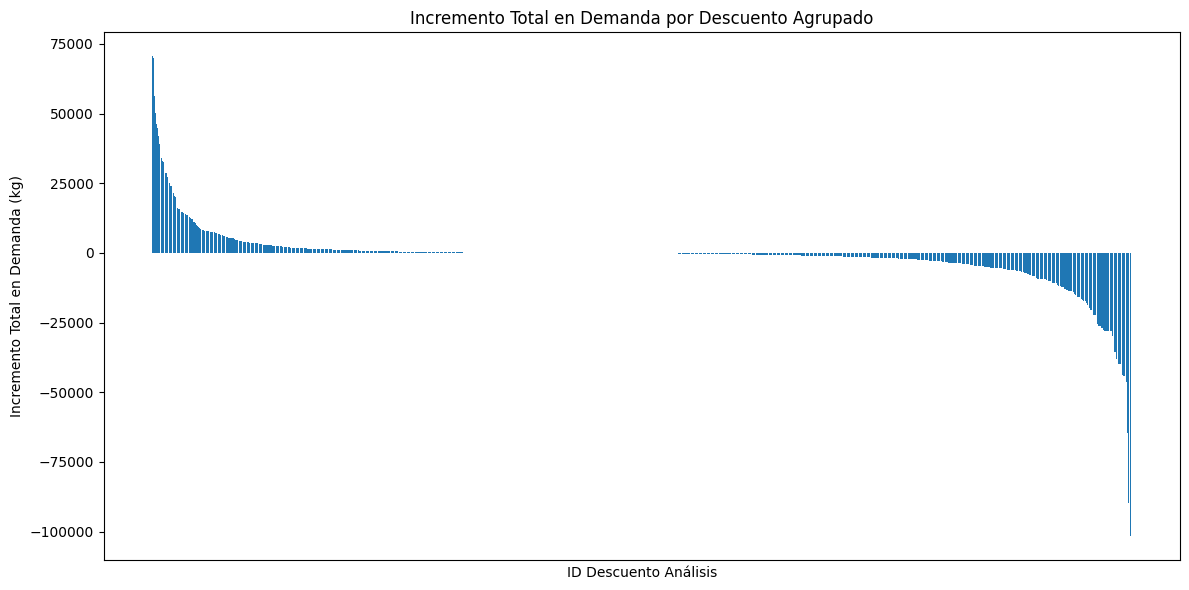

In [41]:
# Graficamos el incremento de demanda de cada descuento agrupado,
# ordenados de mayor a menor en el eje x del gráfico.
data_grafico = resultados_df.sort_values("Incremento Demanda Total (kg)", ascending=False).copy()

# Tratar id como string para que se grafique bien
data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))
plt.bar(
    data_grafico[ID_COL_ANALISIS],
    data_grafico["Incremento Demanda Total (kg)"],
)
plt.title("Incremento Total en Demanda por Descuento Agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Incremento Total en Demanda (kg)")
plt.xticks([])
plt.tight_layout()
plt.show()


Filtrar con los descuentos agrupados cuyo periodo duró 60 días o menos.


## 4.2 Descuentos ordenados por ROP

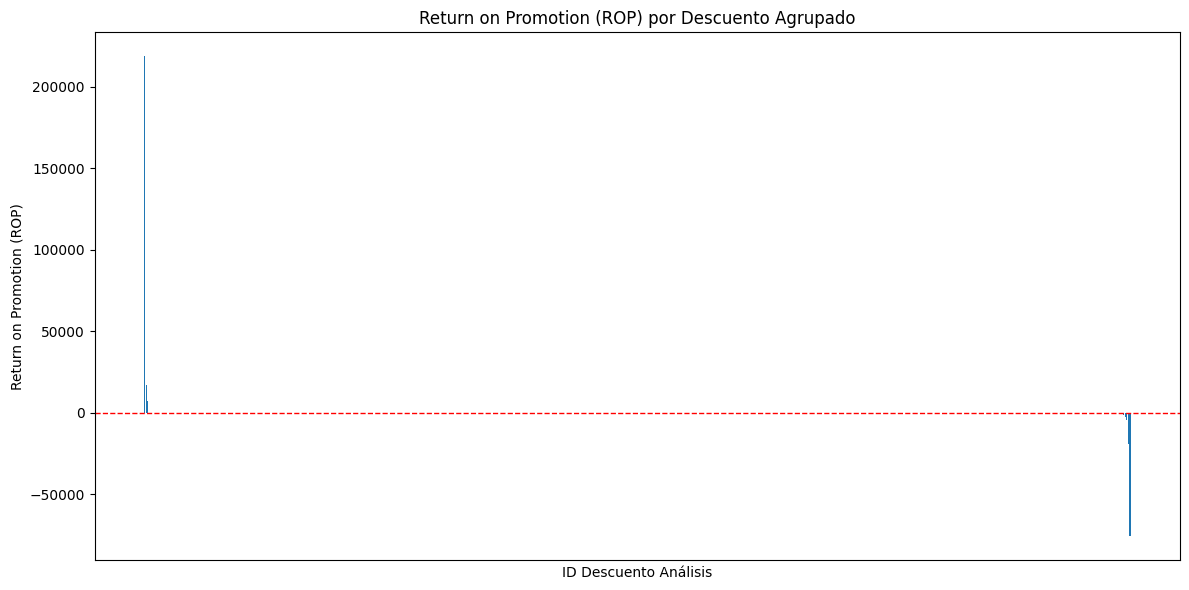

In [42]:
# Graficamos el ROP de cada descuento agrupado, ordenados de mayor a menor
data_grafico = resultados_df.sort_values("ROP", ascending=False).copy()

# Tratar id como string para que se grafique bien
data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))
plt.bar(
    data_grafico[ID_COL_ANALISIS],
    data_grafico["ROP"],
)
plt.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.title("Return on Promotion (ROP) por Descuento Agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Return on Promotion (ROP)")
plt.xticks([])
plt.tight_layout()
plt.show()


In [43]:
tol = 1e-4
condiciones = [
    data_grafico["ROP"] < -10,
    (data_grafico["ROP"] >= -10) & (data_grafico["ROP"] < -1),
    (data_grafico["ROP"] >= -1) & (data_grafico["ROP"] < 0),
    data_grafico["ROP"].abs() <= tol,
    (data_grafico["ROP"] > 0) & (data_grafico["ROP"] <= 1),
    data_grafico["ROP"] > 1
]

labels = [
    "< -10",
    "-10 a -1",
    "-1 a 0",
    "≈ 0",
    "0 a 1",
    "> 1"
]

# crear columna categórica
data_grafico["rango_rop"] = np.select(condiciones, labels, default="otros")

# tabla de conteo
tabla = data_grafico["rango_rop"].value_counts().reindex(labels, fill_value=0).reset_index()
tabla.columns = ["rango_rop", "cantidad"]

print(tabla)

  rango_rop  cantidad
0     < -10        47
1  -10 a -1        59
2    -1 a 0        34
3       ≈ 0         1
4     0 a 1       120
5       > 1       361


In [44]:
data_grafico.columns

Index(['id_descuento_analisis', 'ids_descuento_originales',
       'n_ids_descuento_originales', 'es_descuento_agrupado', 'cod_sku',
       'tipo_descuento', 'cod_canal', 'cod_consolidado', 'fecha_inicio',
       'fecha_fin', 'duracion_dias', 'ROP', 'Incremento Demanda Total (kg)',
       'Margen por kg utilizado ($/kg)', 'Margen incremental bruto ($)',
       'Costo Promoción ($)', 'Contribución neta del descuento ($)',
       'dias_baseline_usados', 'rango_rop'],
      dtype='str')

In [45]:
descuentos_analisis.columns


Index(['id_descuento_analisis', 'cod_sku', 'tipo_descuento', 'cod_canal',
       'cod_consolidado', 'fecha_inicio', 'fecha_fin', 'fecha_fin_original',
       'ids_descuento_originales', 'n_ids_descuento_originales',
       'monto_descuento_min', 'monto_descuento_max', 'duracion_dias',
       'es_descuento_agrupado'],
      dtype='str')

In [46]:
resultados_df.to_csv("resultados_retornos_agrupados.csv", index=False)


In [47]:
type(baseline_cache)

dict

In [48]:
from pathlib import Path
import pickle

output_path = Path("baseline_cache.pkl")
cache_fecha_corte = FECHA_FIN_DATOS_VENTAS.strftime("%Y-%m-%d")
with output_path.open("wb") as f:
    pickle.dump(baseline_cache, f, protocol=pickle.HIGHEST_PROTOCOL)

output_path.resolve()


PosixPath('/Users/summa/Documents/GitHub/ci0103/baseline_cache.pkl')

In [49]:
# Agregar/normalizar tipo_descuento a resultados_df desde descuentos_analisis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def normalizar_tipo_descuento(valor):
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip().lower()

    if valor == "base" or valor.startswith("base"):
        return "base"
    if valor == "binario" or valor.startswith("binario"):
        return "binario"
    if valor == "volumen" or valor.startswith("volumen"):
        return "volumen"

    return valor

# Construir mapa id_descuento_analisis -> tipo_descuento
tipo_por_descuento = (
    descuentos_analisis[[ID_COL_ANALISIS, "tipo_descuento"]]
    .drop_duplicates(ID_COL_ANALISIS)
    .copy()
)

tipo_por_descuento["tipo_descuento"] = tipo_por_descuento["tipo_descuento"].map(
    normalizar_tipo_descuento
)

# Hacer merge sobre resultados_df ya calculado/filtrado
resultados_df = resultados_df.drop(columns=["tipo_descuento"], errors="ignore").merge(
    tipo_por_descuento,
    on=ID_COL_ANALISIS,
    how="left",
)

# Validación solicitada
assert resultados_df["tipo_descuento"].notna().all(), (
    "Hay descuentos en resultados_df sin tipo_descuento. "
    "Revisar ids faltantes: "
    f"{resultados_df.loc[resultados_df['tipo_descuento'].isna(), ID_COL_ANALISIS].tolist()}"
)

print("Tipos de descuento en resultados_df:")
display(resultados_df["tipo_descuento"].value_counts(dropna=False))


Tipos de descuento en resultados_df:


tipo_descuento
binario    717
volumen    393
base       140
Name: count, dtype: int64

In [50]:
# Paleta fija para tipos esperados + fallback para tipos inesperados

paleta_tipo_descuento = {
    "base": "#4C72B0",
    "binario": "#55A868",
    "volumen": "#C44E52",
}

tipos_presentes = sorted(resultados_df["tipo_descuento"].dropna().unique())

tipos_inesperados = [
    tipo for tipo in tipos_presentes
    if tipo not in paleta_tipo_descuento
]

if tipos_inesperados:
    colores_extra = sns.color_palette("tab10", n_colors=len(tipos_inesperados)).as_hex()
    paleta_tipo_descuento.update(dict(zip(tipos_inesperados, colores_extra)))

orden_tipos_descuento = [
    tipo for tipo in ["base", "binario", "volumen"]
    if tipo in tipos_presentes
] + [
    tipo for tipo in tipos_presentes
    if tipo not in ["base", "binario", "volumen"]
]

print("Orden tipos descuento:", orden_tipos_descuento)

Orden tipos descuento: ['base', 'binario', 'volumen']


In [51]:
# Paleta fija para tipos esperados + fallback para tipos inesperados

paleta_tipo_descuento = {
    "base": "#4C72B0",
    "binario": "#55A868",
    "volumen": "#C44E52",
}

tipos_presentes = sorted(resultados_df["tipo_descuento"].dropna().unique())

tipos_inesperados = [
    tipo for tipo in tipos_presentes
    if tipo not in paleta_tipo_descuento
]

if tipos_inesperados:
    colores_extra = sns.color_palette("tab10", n_colors=len(tipos_inesperados)).as_hex()
    paleta_tipo_descuento.update(dict(zip(tipos_inesperados, colores_extra)))

orden_tipos_descuento = [
    tipo for tipo in ["base", "binario", "volumen"]
    if tipo in tipos_presentes
] + [
    tipo for tipo in tipos_presentes
    if tipo not in ["base", "binario", "volumen"]
]

print("Orden tipos descuento:", orden_tipos_descuento)

Orden tipos descuento: ['base', 'binario', 'volumen']


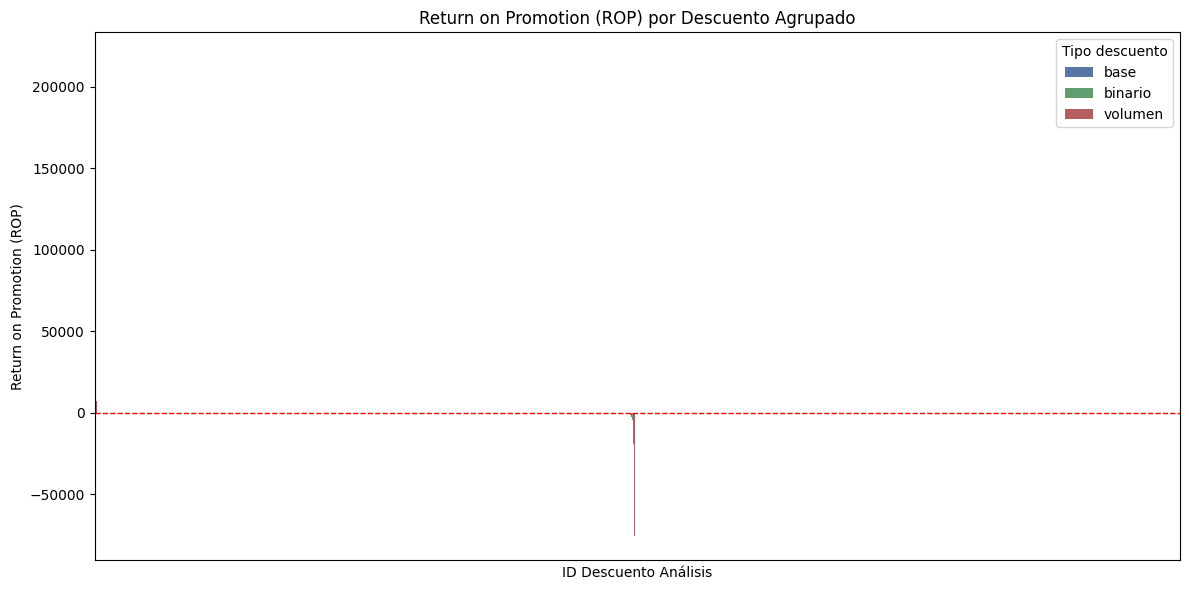

In [52]:
# Gráfico: ROP por descuento agrupado, coloreado por tipo_descuento

data_grafico = resultados_df.sort_values(
    "ROP",
    ascending=False,
).copy()

data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=data_grafico,
    x=ID_COL_ANALISIS,
    y="ROP",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    dodge=False,
)
plt.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.title("Return on Promotion (ROP) por Descuento Agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Return on Promotion (ROP)")
plt.xticks([])
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()


Descuentos Base Analizados: 140


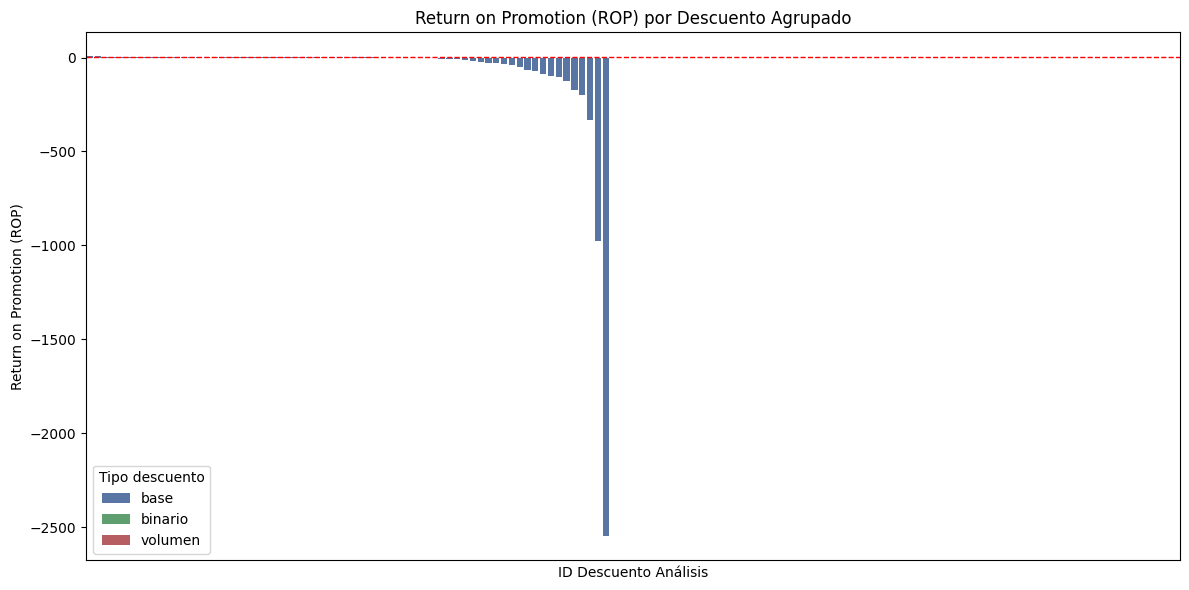

In [53]:
data_grafico = resultados_df[
    resultados_df["tipo_descuento"] == "base"
].sort_values(
    "ROP",
    ascending=False,
).copy()

print(f"Descuentos Base Analizados: {data_grafico.shape[0]}")

data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=data_grafico,
    x=ID_COL_ANALISIS,
    y="ROP",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    dodge=False,
)
plt.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.title("Return on Promotion (ROP) por Descuento Agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Return on Promotion (ROP)")
plt.xticks([])
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

Descuentos Binario Analizados: 717


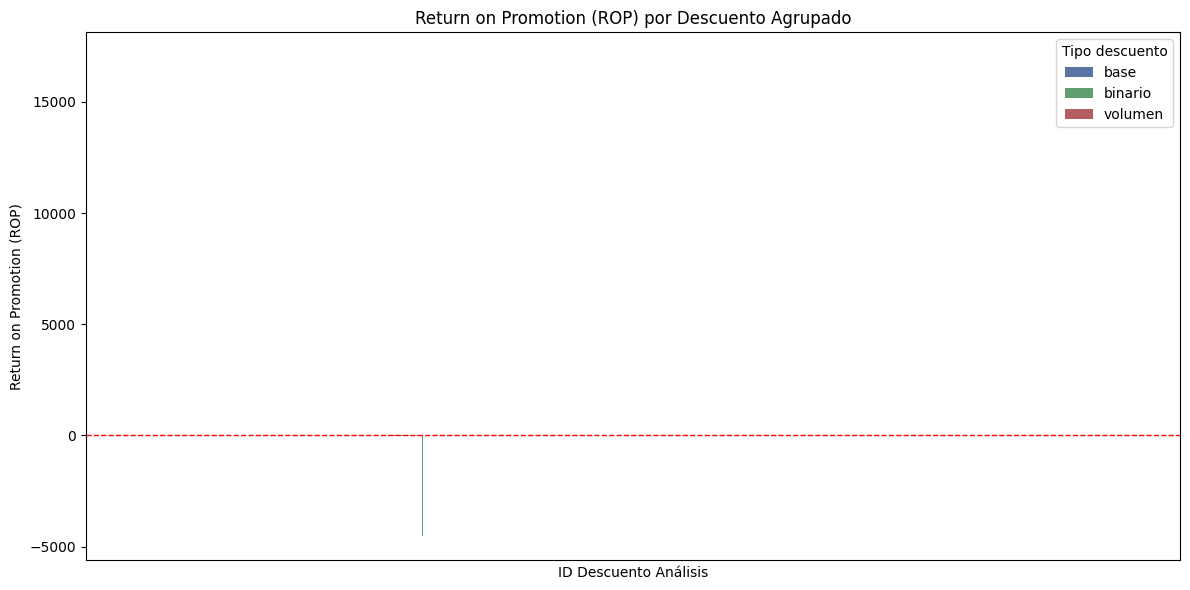

In [54]:
data_grafico = resultados_df[
    resultados_df["tipo_descuento"] == "binario"
].sort_values(
    "ROP",
    ascending=False,
).copy()
print(f"Descuentos Binario Analizados: {data_grafico.shape[0]}")

data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=data_grafico,
    x=ID_COL_ANALISIS,
    y="ROP",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    dodge=False,
)
plt.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.title("Return on Promotion (ROP) por Descuento Agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Return on Promotion (ROP)")
plt.xticks([])
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

Descuentos Volumen Analizados: 393


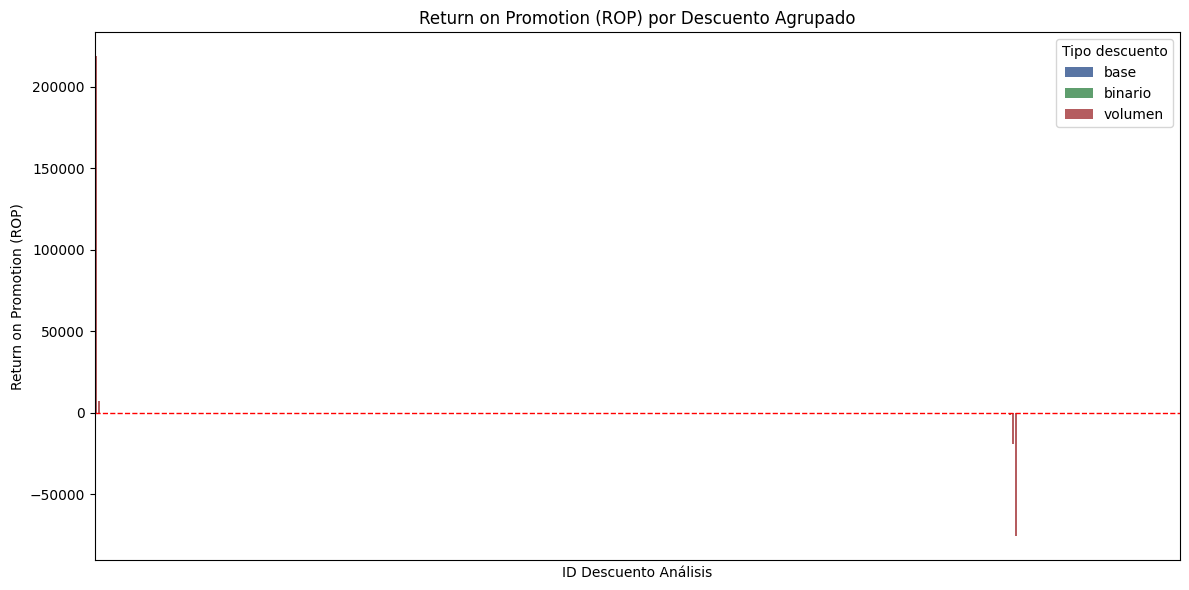

In [55]:
data_grafico = resultados_df[
    resultados_df["tipo_descuento"] == "volumen"
].sort_values(
    "ROP",
    ascending=False,
).copy()
print(f"Descuentos Volumen Analizados: {data_grafico.shape[0]}")


data_grafico[ID_COL_ANALISIS] = data_grafico[ID_COL_ANALISIS].astype(str)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=data_grafico,
    x=ID_COL_ANALISIS,
    y="ROP",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    dodge=False,
)
plt.axhline(y=1, color="red", linestyle="--", linewidth=1)
plt.title("Return on Promotion (ROP) por Descuento Agrupado")
plt.xlabel("ID Descuento Análisis")
plt.ylabel("Return on Promotion (ROP)")
plt.xticks([])
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

In [56]:
# Tabla resumen de rangos ROP por tipo_descuento
data_grafico = resultados_df.sort_values(
    "ROP",
    ascending=False,
).copy()
tol = 1e-4

condiciones = [
    data_grafico["ROP"] < -10,
    (data_grafico["ROP"] >= -10) & (data_grafico["ROP"] < -1),
    (data_grafico["ROP"] >= -1) & (data_grafico["ROP"] < -tol),
    data_grafico["ROP"].abs() <= tol,
    (data_grafico["ROP"] > tol) & (data_grafico["ROP"] <= 1),
    (data_grafico["ROP"] > 1) & (data_grafico["ROP"] <= 2),
    (data_grafico["ROP"] > 2) & (data_grafico["ROP"] <= 5),
    data_grafico["ROP"] > 5,
]

labels = [
    "< -10",
    "-10 a -1",
    "-1 a 0",
    "≈ 0",
    "0 a 1",
    "1 a 2",
    "2 a 5",
    "> 5",
]

data_grafico["rango_rop"] = np.select(
    condiciones,
    labels,
    default="otros"
)

data_grafico["rango_rop"] = pd.Categorical(
    data_grafico["rango_rop"],
    categories=labels,
    ordered=True
)

tabla = (
    pd.crosstab(
        data_grafico["rango_rop"],
        data_grafico["tipo_descuento"]
    )
    .reindex(labels, fill_value=0)
)

# Asegurar columnas esperadas aunque alguna no aparezca en los datos filtrados
for col in ["base", "binario", "volumen"]:
    if col not in tabla.columns:
        tabla[col] = 0

tabla = tabla[["base", "binario", "volumen"]]
tabla["total"] = tabla.sum(axis=1)

tabla = tabla.reset_index()

# Validaciones solicitadas
# assert tabla["total"].sum() == len(data_grafico), (
#     f"La suma de tabla['total']={tabla['total'].sum()} "
#     f"no coincide con len(data_grafico)={len(data_grafico)}"
# )

assert (
    tabla[["base", "binario", "volumen"]].sum(axis=1) == tabla["total"]
).all(), "Las columnas por tipo no suman correctamente el total por rango."

display(tabla)

/var/folders/dw/9r647bwd1kl_g5lxtz0kh4100000gp/T/ipykernel_41449/2248561558.py:36: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  data_grafico["rango_rop"] = pd.Categorical(


tipo_descuento,rango_rop,base,binario,volumen,total
0,< -10,19,4,24,47
1,-10 a -1,9,10,40,59
2,-1 a 0,2,17,15,34
3,≈ 0,0,0,1,1
4,0 a 1,10,58,52,120
5,1 a 2,13,57,43,113
6,2 a 5,12,74,111,197
7,> 5,2,1,48,51


In [57]:
# ------------------------------------------------------------
# 1. Preparar base de análisis
# ------------------------------------------------------------

data_rop = resultados_df.copy()

# Asegurar tipo_descuento si no quedó en resultados_df
if "tipo_descuento" not in data_rop.columns:
    tipo_por_descuento = (
        descuentos_analisis[[ID_COL_ANALISIS, "tipo_descuento"]]
        .drop_duplicates(ID_COL_ANALISIS)
    )

    data_rop = data_rop.merge(
        tipo_por_descuento,
        on=ID_COL_ANALISIS,
        how="left",
    )

# Asegurar monto_descuento_min/max si no quedaron en resultados_df
cols_monto_descuento = ["monto_descuento_min", "monto_descuento_max"]

if not all(col in data_rop.columns for col in cols_monto_descuento):
    monto_por_descuento = (
        descuentos_analisis[
            [ID_COL_ANALISIS, "monto_descuento_min", "monto_descuento_max"]
        ]
        .drop_duplicates(ID_COL_ANALISIS)
    )

    data_rop = data_rop.merge(
        monto_por_descuento,
        on=ID_COL_ANALISIS,
        how="left",
    )

# Monto representativo del descuento.
# Para descuentos de volumen agrupados puede haber varios tramos, por eso usamos el promedio entre min y max.
data_rop["monto_descuento_representativo"] = (
    data_rop[["monto_descuento_min", "monto_descuento_max"]]
    .mean(axis=1)
)

# Filtrar observaciones válidas
data_rop = data_rop[
    data_rop["ROP"].notna()
    & np.isfinite(data_rop["ROP"])
    & data_rop["duracion_dias"].notna()
].copy()

# ------------------------------------------------------------
# 2. Crear rangos de ROP con los mismos intervalos definidos antes
# ------------------------------------------------------------

tol = 1e-4

condiciones = [
    data_rop["ROP"] < -10,
    (data_rop["ROP"] >= -10) & (data_rop["ROP"] < -1),
    (data_rop["ROP"] >= -1) & (data_rop["ROP"] < -tol),
    data_rop["ROP"].abs() <= tol,
    (data_rop["ROP"] > tol) & (data_rop["ROP"] <= 1),
    (data_rop["ROP"] > 1) & (data_rop["ROP"] <= 2),
    (data_rop["ROP"] > 2) & (data_rop["ROP"] <= 5),
    data_rop["ROP"] > 5,
]

labels_rop = [
    "< -10",
    "-10 a -1",
    "-1 a 0",
    "≈ 0",
    "0 a 1",
    "1 a 2",
    "2 a 5",
    "> 5",
]

data_rop["rango_rop"] = np.select(
    condiciones,
    labels_rop,
    default="otros",
)

data_rop["rango_rop"] = pd.Categorical(
    data_rop["rango_rop"],
    categories=labels_rop,
    ordered=True,
)

In [58]:

# ------------------------------------------------------------
# 3. Tabla: distribución de duración de descuentos por rango de ROP
# ------------------------------------------------------------

tabla_duracion_por_rop = (
    data_rop
    .groupby("rango_rop", observed=False)
    .agg(
        n_descuentos=(ID_COL_ANALISIS, "nunique"),
        duracion_promedio_dias=("duracion_dias", "mean"),
        duracion_mediana_dias=("duracion_dias", "median"),
        duracion_min_dias=("duracion_dias", "min"),
        duracion_p25_dias=("duracion_dias", lambda x: x.quantile(0.25)),
        duracion_p75_dias=("duracion_dias", lambda x: x.quantile(0.75)),
        duracion_max_dias=("duracion_dias", "max"),
        rop_promedio=("ROP", "mean"),
        rop_mediana=("ROP", "median"),
    )
    .reset_index()
)

tabla_duracion_por_rop = tabla_duracion_por_rop.round({
    "duracion_promedio_dias": 1,
    "duracion_mediana_dias": 1,
    "duracion_p25_dias": 1,
    "duracion_p75_dias": 1,
    "rop_promedio": 2,
    "rop_mediana": 2,
})

display(tabla_duracion_por_rop)

,rango_rop,n_descuentos,duracion_promedio_dias,duracion_mediana_dias,duracion_min_dias,duracion_p25_dias,duracion_p75_dias,duracion_max_dias,rop_promedio,rop_mediana
0,< -10,47,93.4,30.0,1,4.0,172.0,343,-2269.10,-32.93
1,-10 a -1,59,30.8,23.0,2,6.0,32.0,287,-3.14,-2.07
2,-1 a 0,34,21.6,27.0,2,11.5,30.0,34,-0.40,-0.32
3,≈ 0,1,2.0,2.0,2,2.0,2.0,2,0.00,0.00
4,0 a 1,120,20.9,27.0,1,6.0,30.0,34,0.57,0.64
5,1 a 2,113,20.2,27.0,1,7.0,30.0,34,1.48,1.48
6,2 a 5,197,21.6,27.0,2,13.0,30.0,34,3.14,3.12
7,> 5,51,15.8,13.0,1,2.0,30.0,34,4777.70,8.13


In [59]:

# ------------------------------------------------------------
# 4. Paleta para pintar por tipo de descuento
# ------------------------------------------------------------

paleta_tipo_descuento = {
    "base": "#4C72B0",
    "binario": "#55A868",
    "volumen": "#C44E52",
}

tipos_presentes = sorted(data_rop["tipo_descuento"].dropna().unique())

tipos_inesperados = [
    tipo for tipo in tipos_presentes
    if tipo not in paleta_tipo_descuento
]

if tipos_inesperados:
    colores_extra = sns.color_palette("tab10", n_colors=len(tipos_inesperados)).as_hex()
    paleta_tipo_descuento.update(dict(zip(tipos_inesperados, colores_extra)))

orden_tipos_descuento = [
    tipo for tipo in ["base", "binario", "volumen"]
    if tipo in tipos_presentes
] + [
    tipo for tipo in tipos_presentes
    if tipo not in ["base", "binario", "volumen"]
]


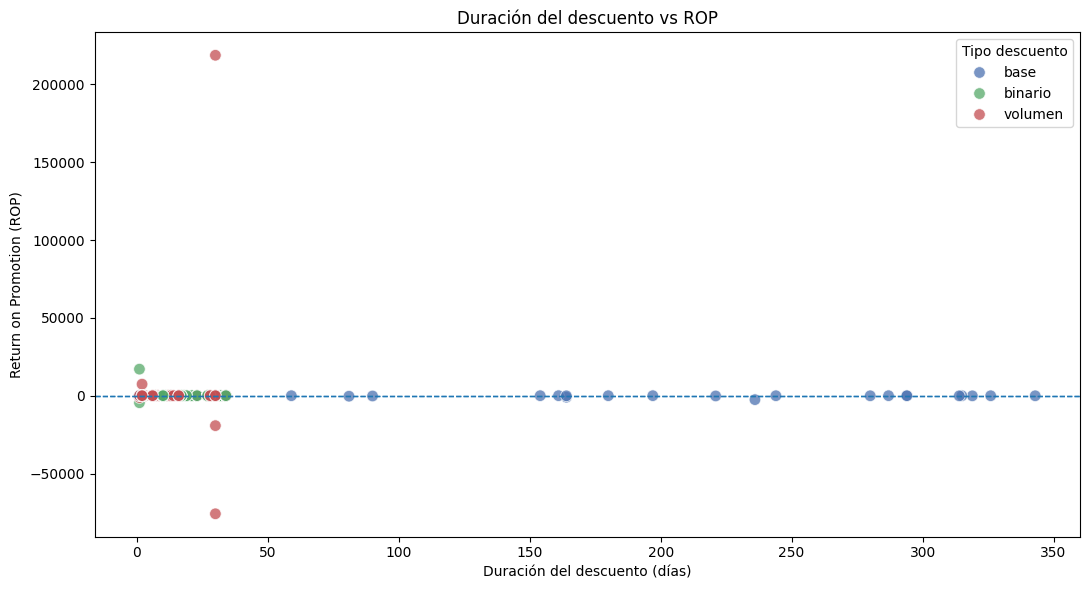

In [60]:
# ------------------------------------------------------------
# 5. Scatterplot: duración del descuento vs ROP
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=data_rop,
    x="duracion_dias",
    y="ROP",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    alpha=0.75,
    s=70,
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)

plt.title("Duración del descuento vs ROP")
plt.xlabel("Duración del descuento (días)")
plt.ylabel("Return on Promotion (ROP)")
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

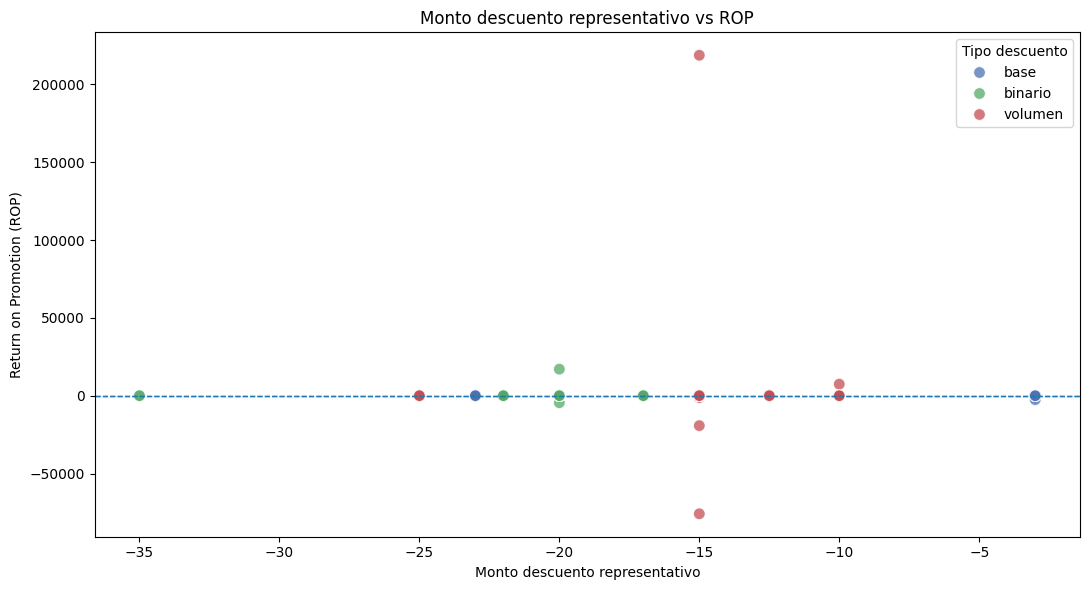

In [61]:
# ------------------------------------------------------------
# 6. Scatterplot: monto descuento representativo vs ROP
# ------------------------------------------------------------

data_monto = data_rop[
    data_rop["monto_descuento_representativo"].notna()
].copy()

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=data_monto,
    x="monto_descuento_representativo",
    y="ROP",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    alpha=0.75,
    s=70,
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)

plt.title("Monto descuento representativo vs ROP")
plt.xlabel("Monto descuento representativo")
plt.ylabel("Return on Promotion (ROP)")
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

In [62]:
# DOBLE CLICK DE LOS MONTOS DE DESCUENTO BINARIO

In [63]:
# ============================================================
# Duración del baseline utilizado vs ROP
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Reconstruir duración del baseline con la misma lógica de analizar_descuento()
# ------------------------------------------------------------

def calcular_info_baseline_para_descuento(descuento):
    sku = descuento["cod_sku"]
    canal = descuento["cod_canal"]
    consolidado = descuento["cod_consolidado"]

    ventas_llave = filtrar_ventas_por_llave(
        ventas,
        sku,
        canal,
        consolidado,
    )

    # Misma lógica del notebook: ventas explícitamente sin descuento
    ventas_sin_descuento = ventas_llave[
        ventas_llave["descuento_aplicado"] == "ninguno"
    ].copy()

    # Mismo fallback del notebook: si no hay ventas sin descuento,
    # usar ventas al precio máximo dentro de la llave
    uso_fallback_precio_maximo = False

    if ventas_sin_descuento.shape[0] == 0 and ventas_llave.shape[0] > 0:
        precio_maximo_muestra = ventas_llave["precio_real"].max()
        ventas_sin_descuento = ventas_llave[
            ventas_llave["precio_real"] == precio_maximo_muestra
        ].copy()
        uso_fallback_precio_maximo = True

    if ventas_sin_descuento.empty:
        return pd.Series({
            "dias_baseline_usados": np.nan,
            "fecha_min_baseline": pd.NaT,
            "fecha_max_baseline": pd.NaT,
            "span_calendario_baseline_dias": np.nan,
            "n_transacciones_baseline": 0,
            "kg_baseline": np.nan,
            "uso_fallback_precio_maximo": uso_fallback_precio_maximo,
        })

    ventas_sin_descuento["fecha_factura"] = pd.to_datetime(
        ventas_sin_descuento["fecha_factura"]
    )

    fecha_min = ventas_sin_descuento["fecha_factura"].min()
    fecha_max = ventas_sin_descuento["fecha_factura"].max()

    return pd.Series({
        # Esta es la duración efectivamente usada como denominador en analizar_descuento()
        "dias_baseline_usados": ventas_sin_descuento["fecha_factura"].nunique(),

        # Esto es solo referencia adicional: ventana calendario cubierta por la muestra
        "fecha_min_baseline": fecha_min,
        "fecha_max_baseline": fecha_max,
        "span_calendario_baseline_dias": (fecha_max - fecha_min).days + 1,

        "n_transacciones_baseline": len(ventas_sin_descuento),
        "kg_baseline": ventas_sin_descuento["kilo_real"].sum(),
        "uso_fallback_precio_maximo": uso_fallback_precio_maximo,
    })


info_baseline = descuentos_analisis.apply(
    calcular_info_baseline_para_descuento,
    axis=1,
)

baseline_por_descuento = pd.concat(
    [
        descuentos_analisis[
            [
                ID_COL_ANALISIS,
                "cod_sku",
                "tipo_descuento",
                "cod_canal",
                "cod_consolidado",
                "fecha_inicio",
                "fecha_fin",
                "duracion_dias",
            ]
        ].reset_index(drop=True),
        info_baseline.reset_index(drop=True),
    ],
    axis=1,
)

# ------------------------------------------------------------
# 2. Unir con resultados de ROP
# ------------------------------------------------------------

columnas_baseline_merge = [
    ID_COL_ANALISIS,
    "dias_baseline_usados",
    "fecha_min_baseline",
    "fecha_max_baseline",
    "span_calendario_baseline_dias",
    "n_transacciones_baseline",
    "kg_baseline",
    "uso_fallback_precio_maximo",
]

if "dias_baseline_usados" in resultados_df.columns:
    columnas_baseline_merge = [
        col for col in columnas_baseline_merge
        if col != "dias_baseline_usados"
    ]

data_baseline_rop = resultados_df.merge(
    baseline_por_descuento[columnas_baseline_merge],
    on=ID_COL_ANALISIS,
    how="left",
)

data_baseline_rop = data_baseline_rop[
    data_baseline_rop["ROP"].notna()
    & np.isfinite(data_baseline_rop["ROP"])
    & data_baseline_rop["dias_baseline_usados"].notna()
    & (data_baseline_rop["dias_baseline_usados"] > 0)
].copy()

# ------------------------------------------------------------
# 3. Crear rangos de ROP
# ------------------------------------------------------------

tol = 1e-4

condiciones = [
    data_baseline_rop["ROP"] < -10,
    (data_baseline_rop["ROP"] >= -10) & (data_baseline_rop["ROP"] < -1),
    (data_baseline_rop["ROP"] >= -1) & (data_baseline_rop["ROP"] < -tol),
    data_baseline_rop["ROP"].abs() <= tol,
    (data_baseline_rop["ROP"] > tol) & (data_baseline_rop["ROP"] <= 1),
    (data_baseline_rop["ROP"] > 1) & (data_baseline_rop["ROP"] <= 2),
    (data_baseline_rop["ROP"] > 2) & (data_baseline_rop["ROP"] <= 5),
    data_baseline_rop["ROP"] > 5,
]

labels_rop = [
    "< -10",
    "-10 a -1",
    "-1 a 0",
    "≈ 0",
    "0 a 1",
    "1 a 2",
    "2 a 5",
    "> 5",
]

data_baseline_rop["rango_rop"] = np.select(
    condiciones,
    labels_rop,
    default="otros",
)

data_baseline_rop["rango_rop"] = pd.Categorical(
    data_baseline_rop["rango_rop"],
    categories=labels_rop,
    ordered=True,
)

# ------------------------------------------------------------
# 4. Tabla: duración del baseline por rango de ROP
# ------------------------------------------------------------

tabla_baseline_por_rop = (
    data_baseline_rop
    .groupby("rango_rop", observed=False)
    .agg(
        n_descuentos=(ID_COL_ANALISIS, "nunique"),
        dias_baseline_promedio=("dias_baseline_usados", "mean"),
        dias_baseline_mediana=("dias_baseline_usados", "median"),
        dias_baseline_min=("dias_baseline_usados", "min"),
        dias_baseline_p25=("dias_baseline_usados", lambda x: x.quantile(0.25)),
        dias_baseline_p75=("dias_baseline_usados", lambda x: x.quantile(0.75)),
        dias_baseline_max=("dias_baseline_usados", "max"),
        span_calendario_mediana=("span_calendario_baseline_dias", "median"),
        pct_con_fallback_precio_maximo=("uso_fallback_precio_maximo", "mean"),
        rop_mediana=("ROP", "median"),
    )
    .reset_index()
)

tabla_baseline_por_rop["pct_con_fallback_precio_maximo"] = (
    tabla_baseline_por_rop["pct_con_fallback_precio_maximo"] * 100
)

tabla_baseline_por_rop = tabla_baseline_por_rop.round({
    "dias_baseline_promedio": 1,
    "dias_baseline_mediana": 1,
    "dias_baseline_p25": 1,
    "dias_baseline_p75": 1,
    "span_calendario_mediana": 1,
    "pct_con_fallback_precio_maximo": 1,
    "rop_mediana": 2,
})

display(tabla_baseline_por_rop)

# ------------------------------------------------------------
# 5. Scatterplot: duración del baseline vs ROP, pintado por tipo de descuento
# ------------------------------------------------------------

paleta_tipo_descuento = {
    "base": "#4C72B0",
    "binario": "#55A868",
    "volumen": "#C44E52",
}

tipos_presentes = sorted(data_baseline_rop["tipo_descuento"].dropna().unique())

tipos_inesperados = [
    tipo for tipo in tipos_presentes
    if tipo not in paleta_tipo_descuento
]

if tipos_inesperados:
    colores_extra = sns.color_palette("tab10", n_colors=len(tipos_inesperados)).as_hex()
    paleta_tipo_descuento.update(dict(zip(tipos_inesperados, colores_extra)))

orden_tipos_descuento = [
    tipo for tipo in ["base", "binario", "volumen"]
    if tipo in tipos_presentes
] + [
    tipo for tipo in tipos_presentes
    if tipo not in ["base", "binario", "volumen"]
]

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=data_baseline_rop,
    x="dias_baseline_usados",
    y="ROP",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    alpha=0.75,
    s=70,
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)

plt.title("Duración del baseline utilizado vs ROP")
plt.xlabel("Días únicos usados para calcular el baseline")
plt.ylabel("Return on Promotion (ROP)")
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Versión opcional con eje X en log, útil si hay mucha dispersión
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=data_baseline_rop,
    x="dias_baseline_usados",
    y="ROP",
    hue="tipo_descuento",
    hue_order=orden_tipos_descuento,
    palette=paleta_tipo_descuento,
    alpha=0.75,
    s=70,
)

plt.xscale("log")
plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)

plt.title("Duración del baseline utilizado vs ROP — eje X log")
plt.xlabel("Días únicos usados para calcular el baseline, escala log")
plt.ylabel("Return on Promotion (ROP)")
plt.legend(title="Tipo descuento")
plt.tight_layout()
plt.show()

KeyboardInterrupt: 